# Visualisation of the continuous drift measurements 

### Example for 1 file

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 1. LOAD
G_cont = pd.read_csv("Continuous_files_basement/20240708_basementIPNA.csv")
#G_cont

In [3]:
# 2. TIMELINE
G_cont['datetime'] = pd.to_datetime(G_cont['Date'] + ' ' + G_cont['Time'])
start_date = G_cont['datetime'].min()
end_date = G_cont['datetime'].max()

duration_days = (end_date - start_date).total_seconds() / 86400

print("Start date :", start_date)
print("End date   :", end_date)
print("Duration days :", duration_days)

Start date : 2024-06-27 12:37:00
End date   : 2024-07-08 06:47:30
Duration days : 10.757291666666667


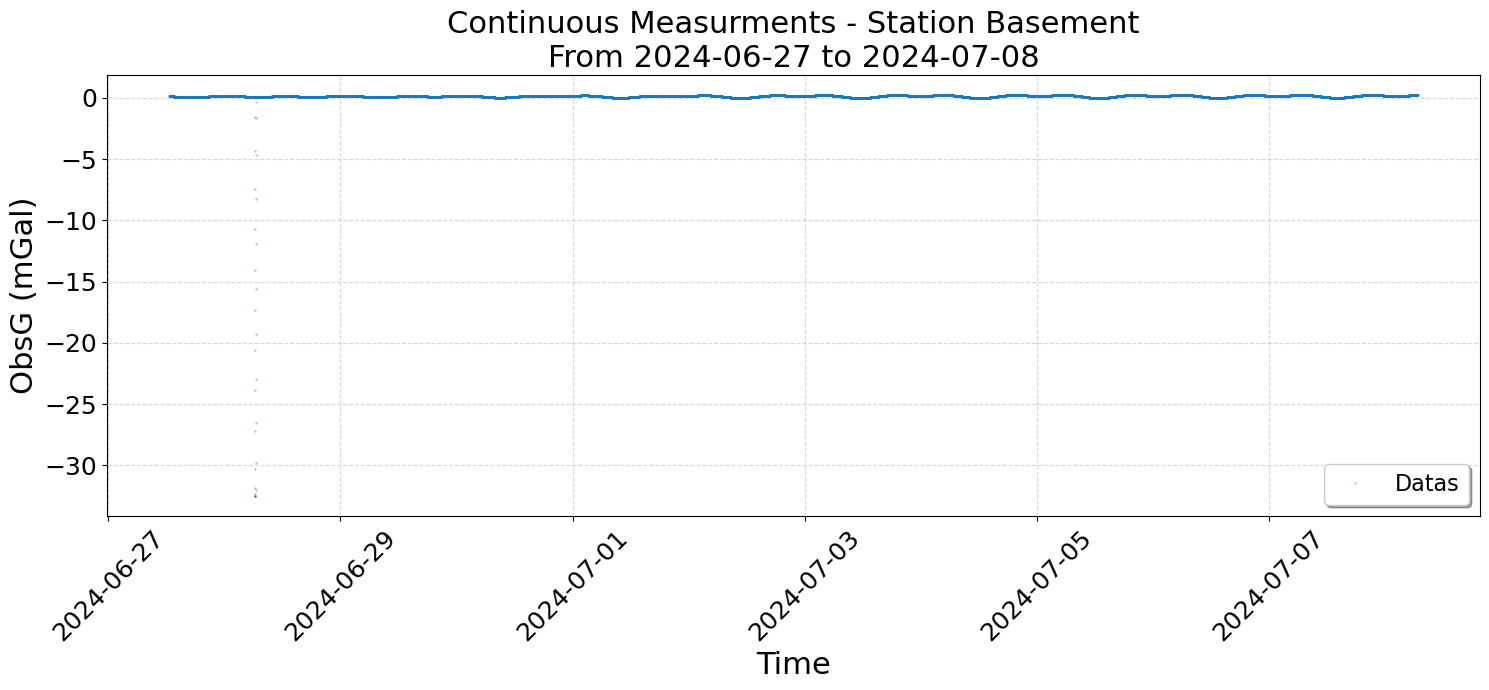

In [4]:
# PLOT 
plt.figure(figsize=(15, 7))
plt.plot(G_cont['datetime'], G_cont['ObsG'], 'o', markersize=0.5, alpha=0.5, label='Datas')
plt.title(f"Continuous Measurments - Station Basement\nFrom {start_date.date()} to {end_date.date()}",fontsize=22)
plt.xlabel("Time", fontsize=22)
plt.ylabel("ObsG (mGal)", fontsize=22)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(fontsize=16, loc='best', frameon=True, shadow=True)
plt.xticks(rotation=45, fontsize=18) 
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

## ALL DATAS

22 files
500626 lines
Max : 1.096 mGal
Min : -32.510 mGal
Mean : 0.205 mGal
Start date    : 2024-04-04 11:16:00
End date      : 2024-10-21 09:35:00
Duration days : 199.93 days


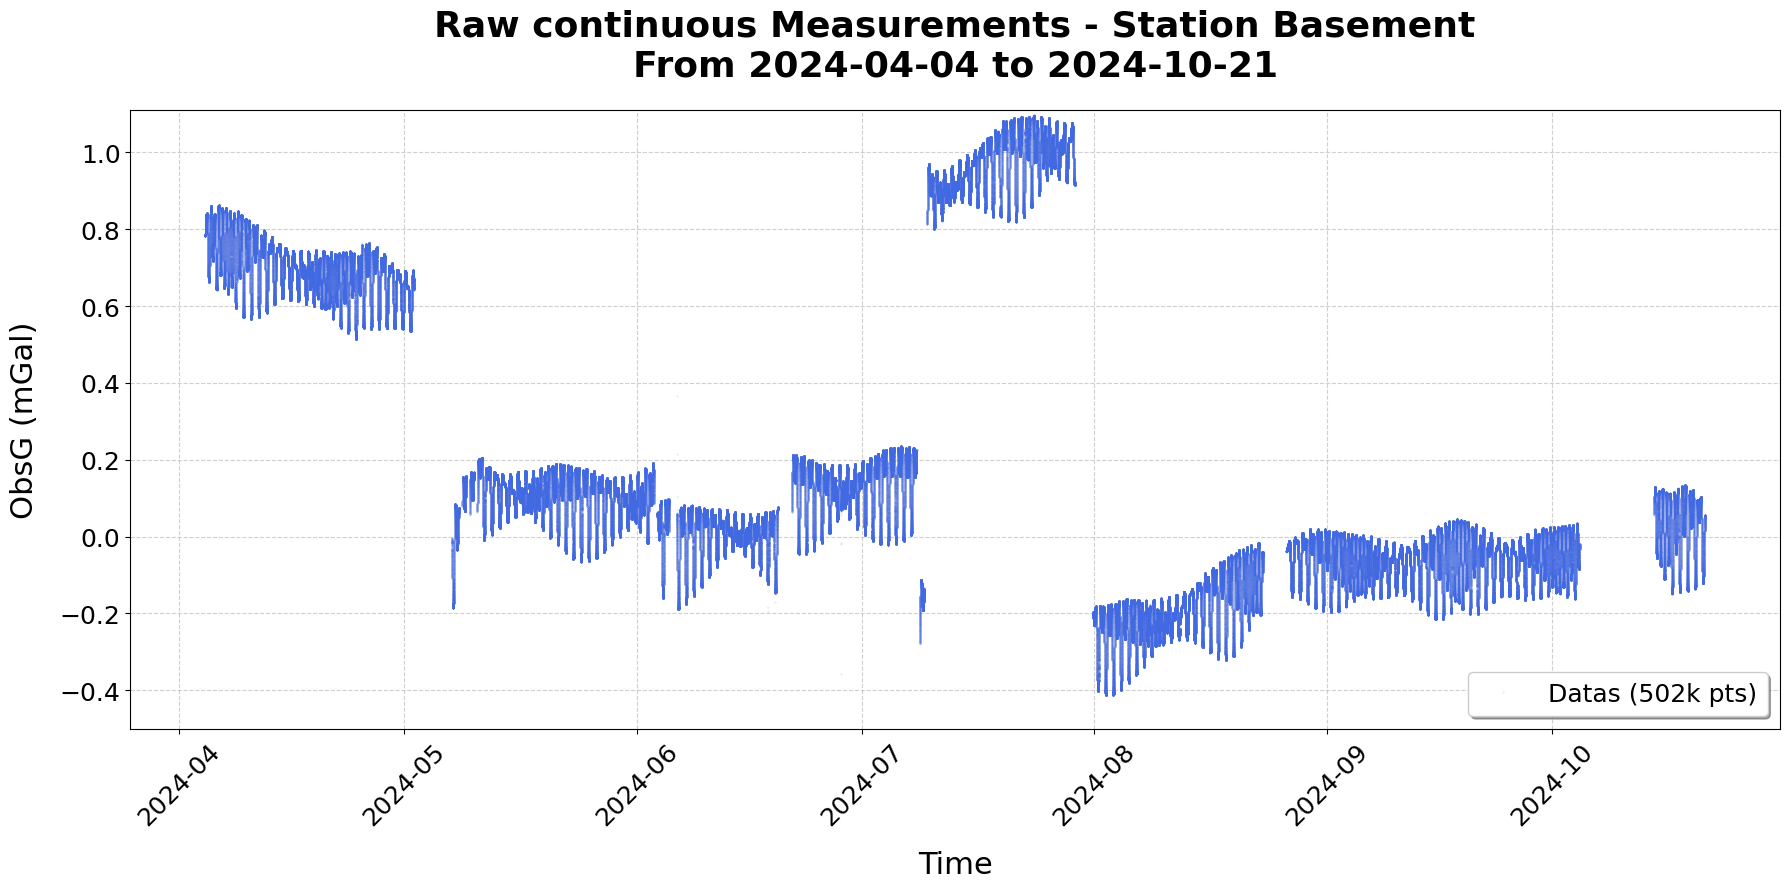

In [5]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# 1. LOAD
path = "Continuous_files_basement/"
all_files = glob.glob(os.path.join(path, "*.csv"))
all_files.sort() 

df_list = [pd.read_csv(f) for f in all_files]
G_total = pd.concat(df_list, ignore_index=True)

print(f"{len(all_files)} files")
print(f"{len(G_total)} lines")

val_max = G_total['ObsG'].max()
val_min = G_total['ObsG'].min()
val_mean = G_total['ObsG'].mean()
print(f"Max : {val_max:.3f} mGal")
print(f"Min : {val_min:.3f} mGal")
print(f"Mean : {val_mean:.3f} mGal")

# 2. TIMELINE
G_total['datetime'] = pd.to_datetime(G_total['Date'] + ' ' + G_total['Time'])
G_total = G_total.sort_values('datetime')

start_date = G_total['datetime'].min()
end_date = G_total['datetime'].max()
duration_days = (end_date - start_date).total_seconds() / 86400

print(f"Start date    : {start_date}")
print(f"End date      : {end_date}")
print(f"Duration days : {duration_days:.2f} days")

# 4. PLOT 
plt.figure(figsize=(18, 9))

plt.plot(G_total['datetime'], G_total['ObsG'], 'o', markersize=0.2, alpha=0.4, color='royalblue', label='Datas (502k pts)')

plt.title(f"Raw continuous Measurements - Station Basement\nFrom {start_date.date()} to {end_date.date()}", fontsize=26, fontweight='bold', pad=25)
plt.xlabel("Time", fontsize=22, labelpad=15)
plt.ylabel("ObsG (mGal)", fontsize=22, labelpad=15)
plt.ylim(-0.5,1.11)

plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(fontsize=18, loc='lower right', frameon=True, shadow=True)

plt.xticks(rotation=45, fontsize=18) 
plt.yticks(fontsize=18)

plt.tight_layout()
plt.show()

### All files plotted one by one

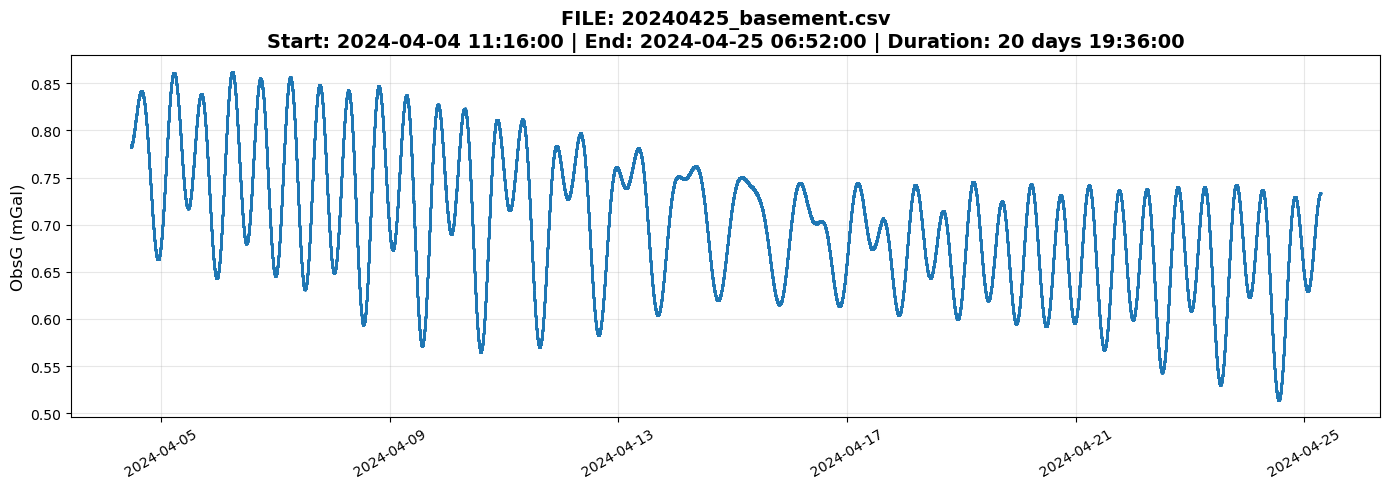

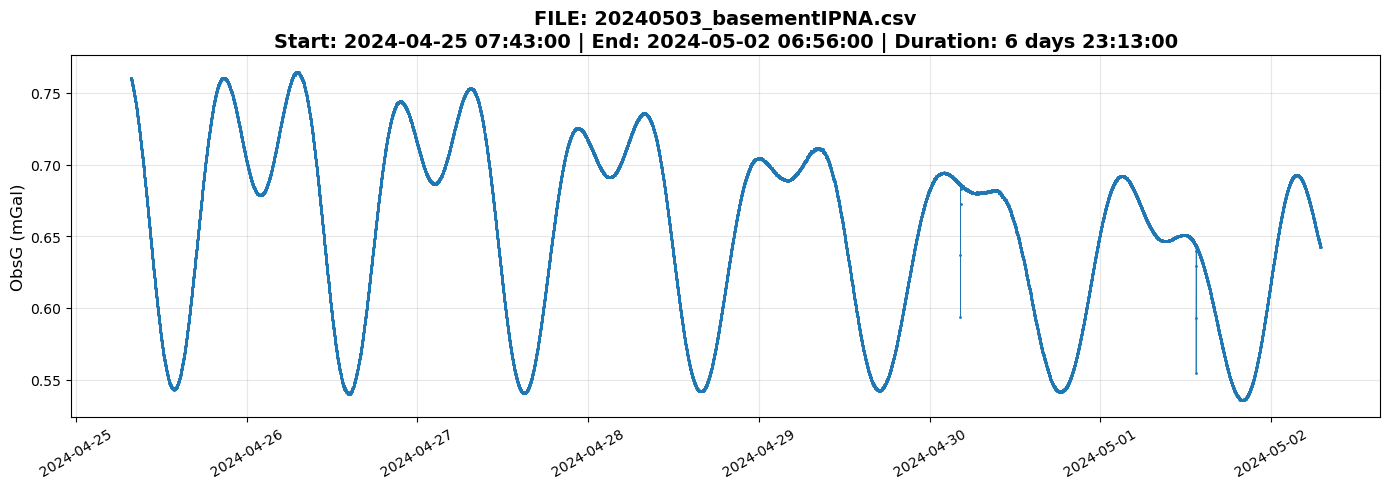

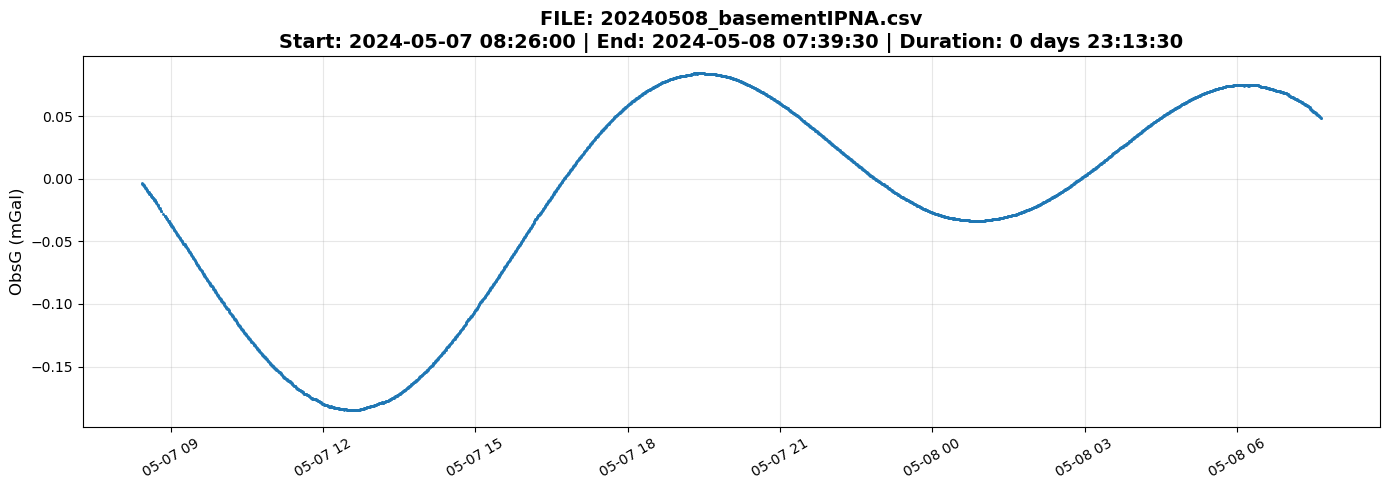

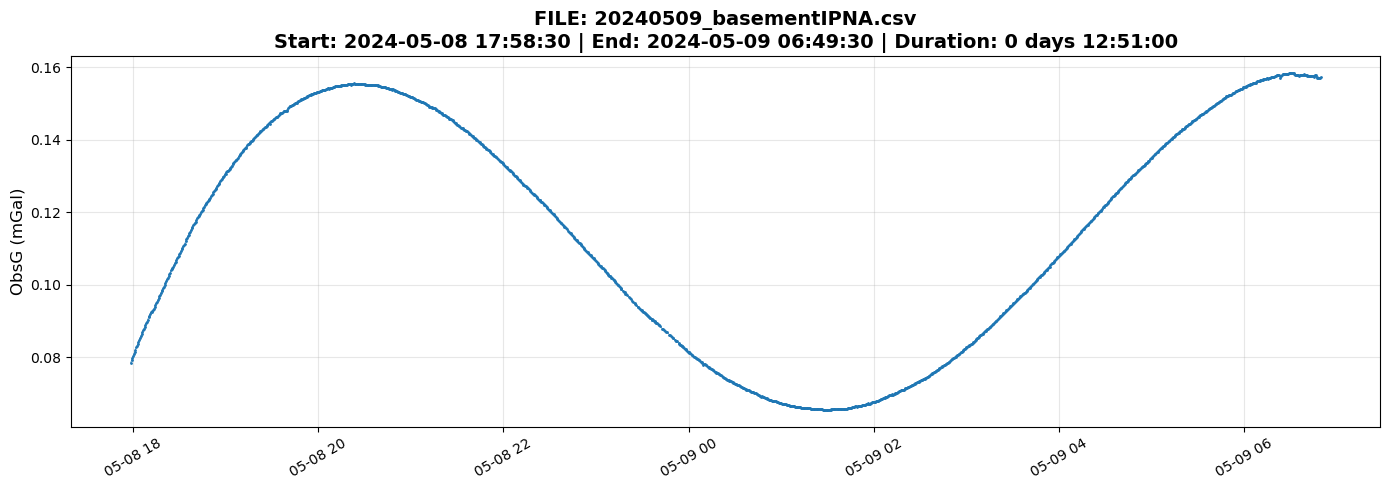

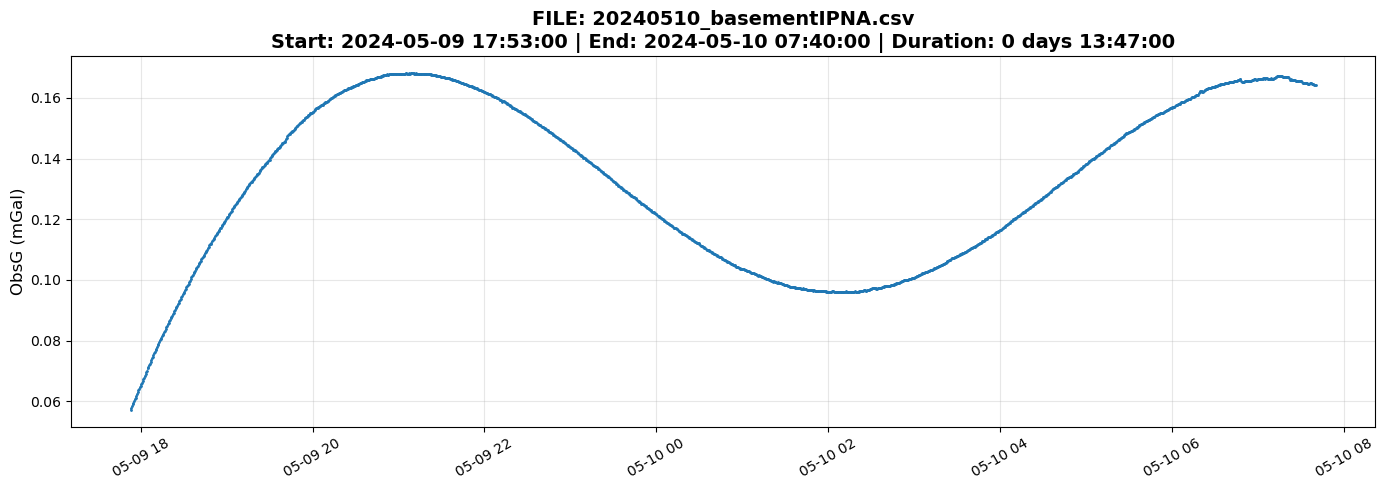

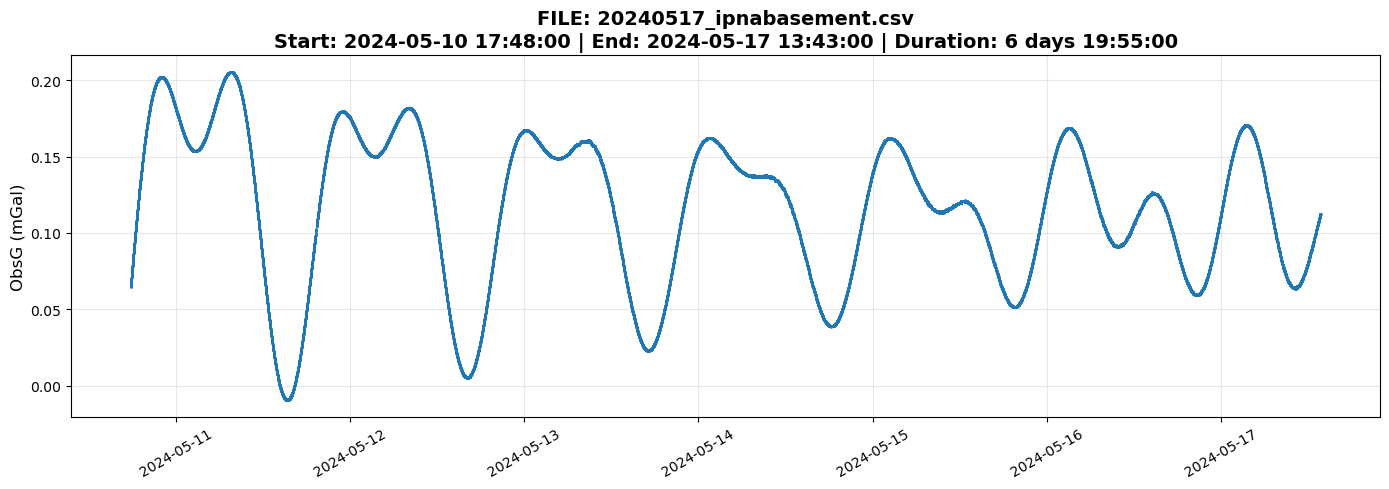

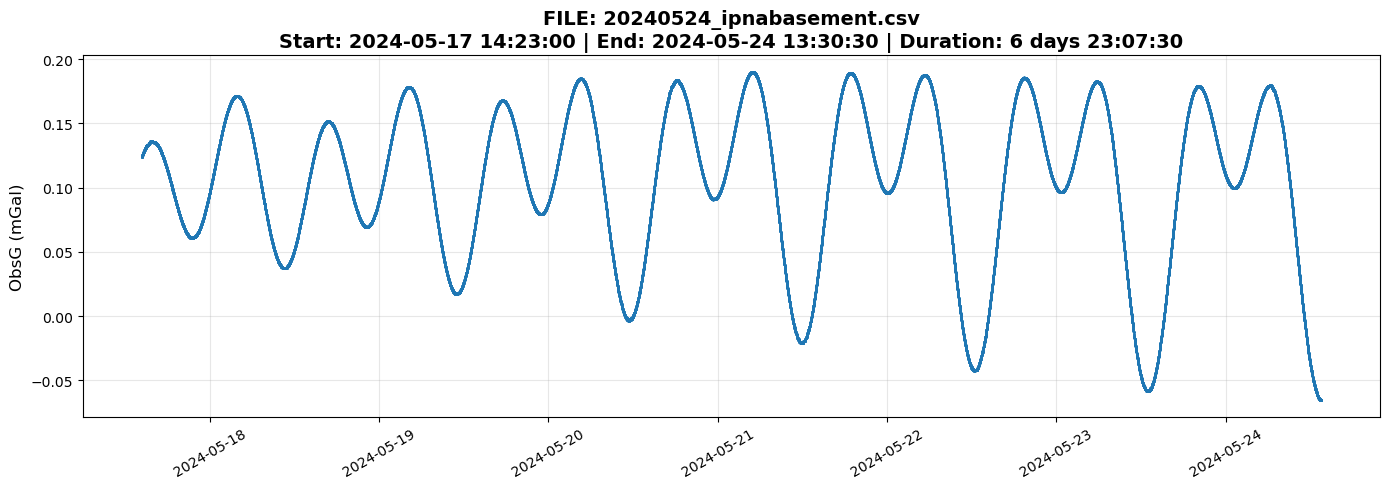

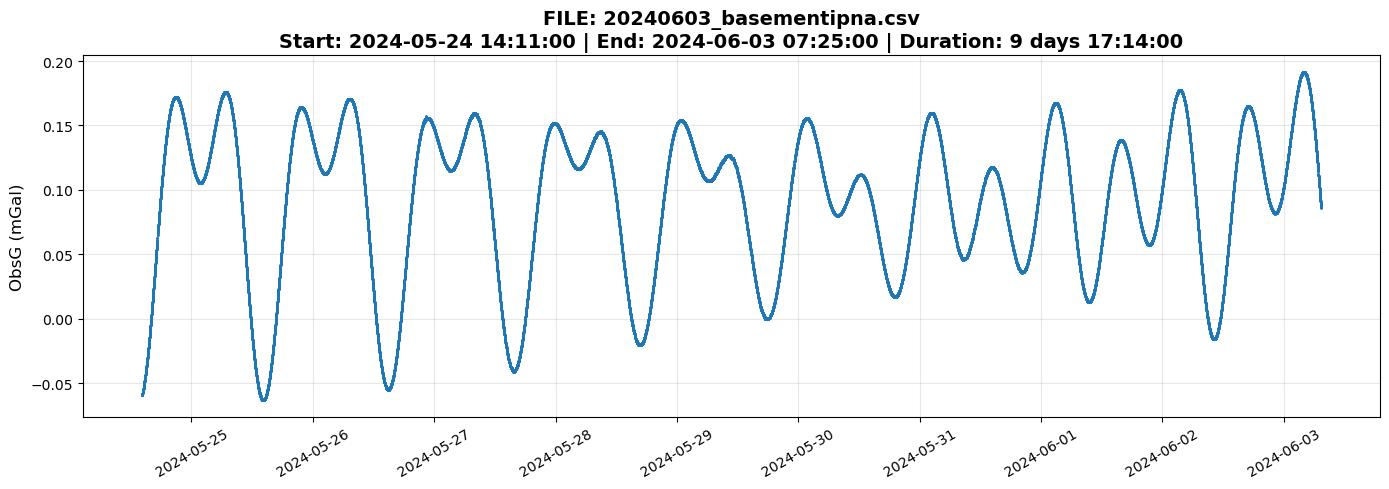

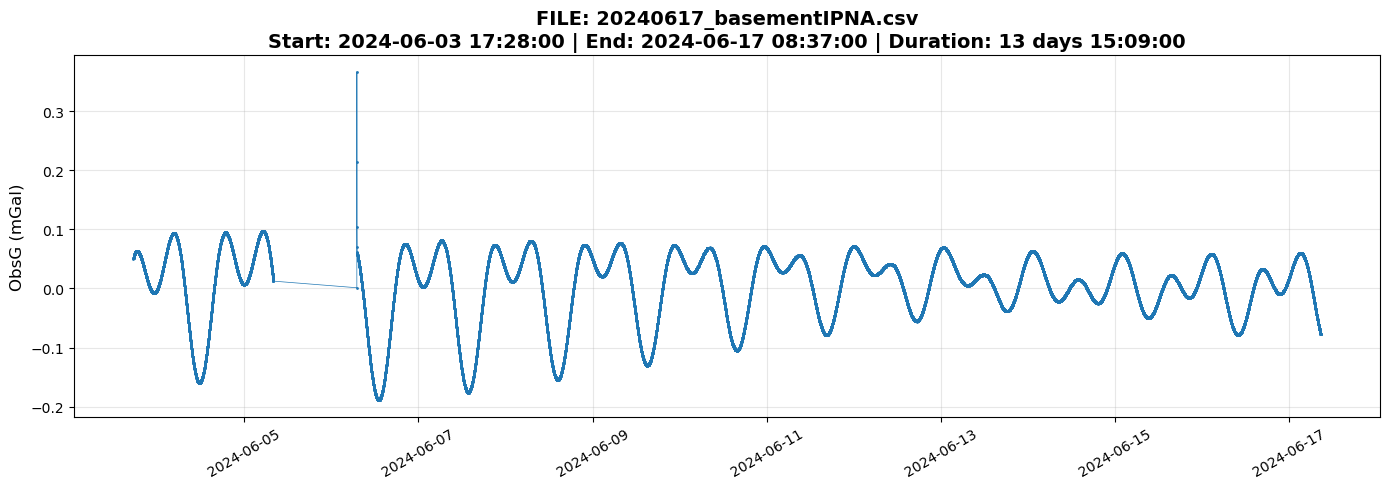

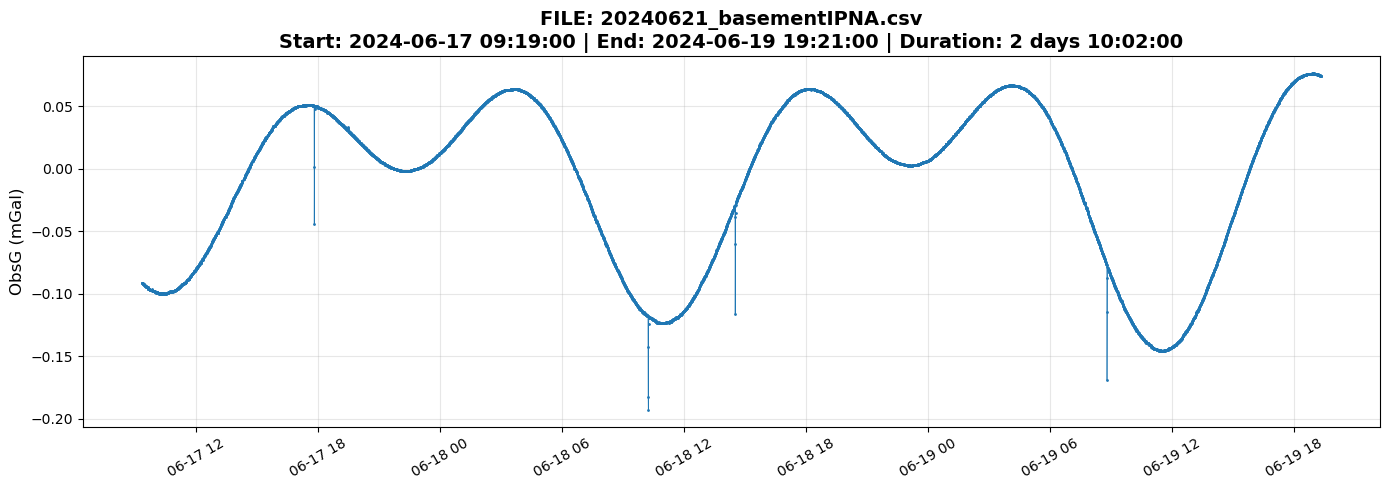

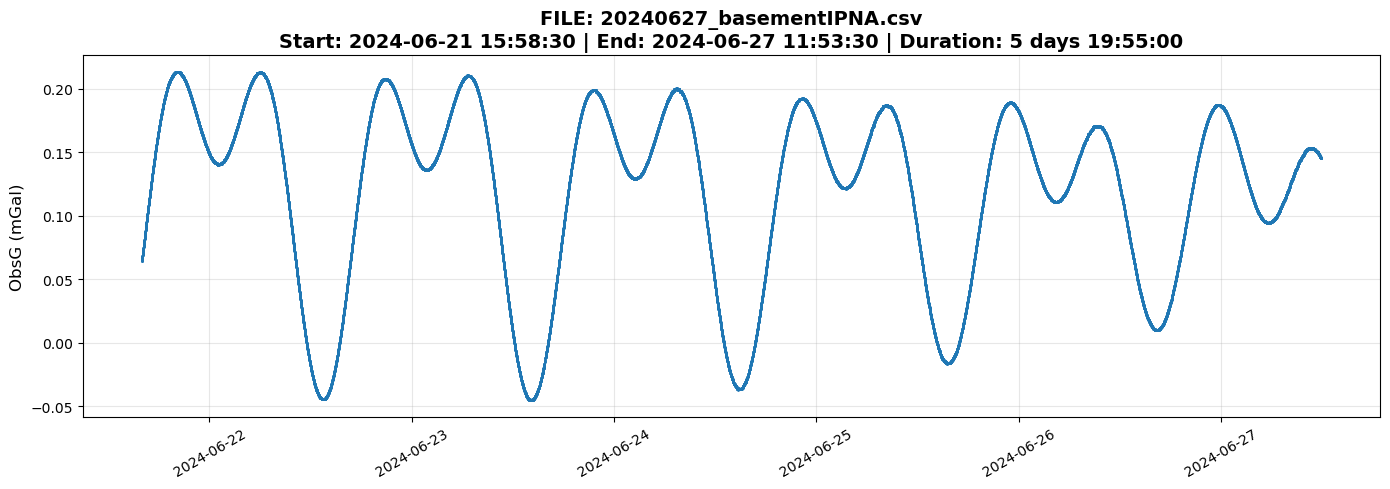

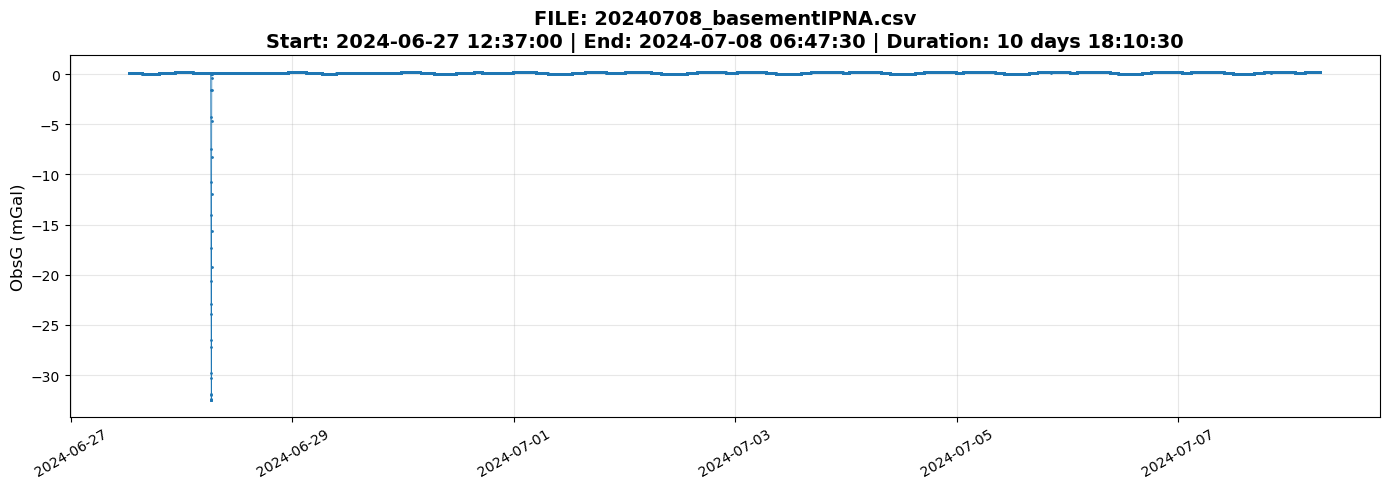

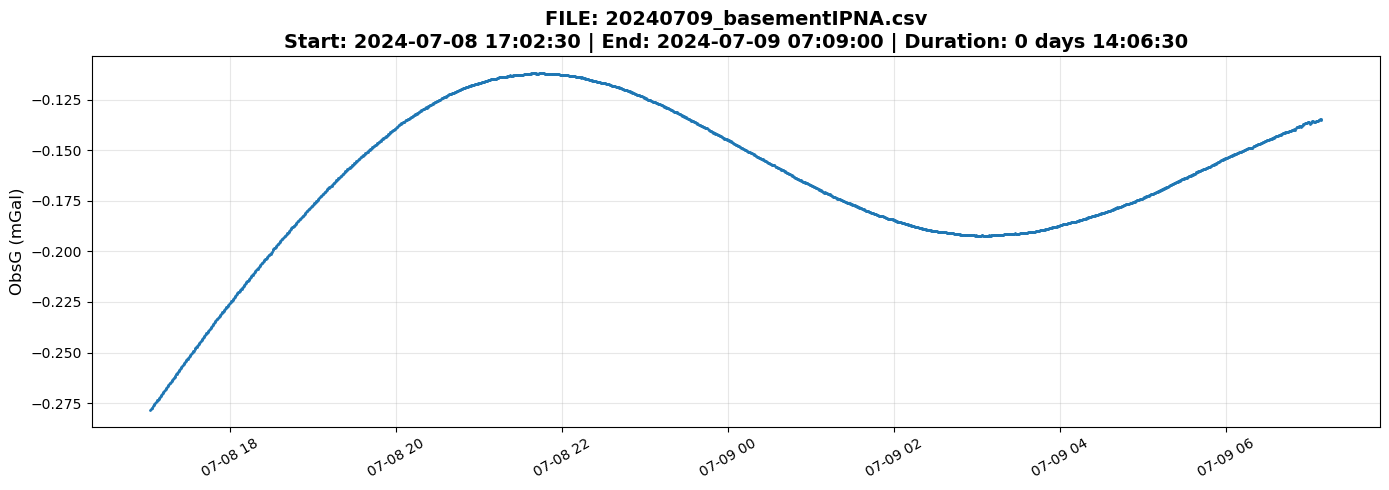

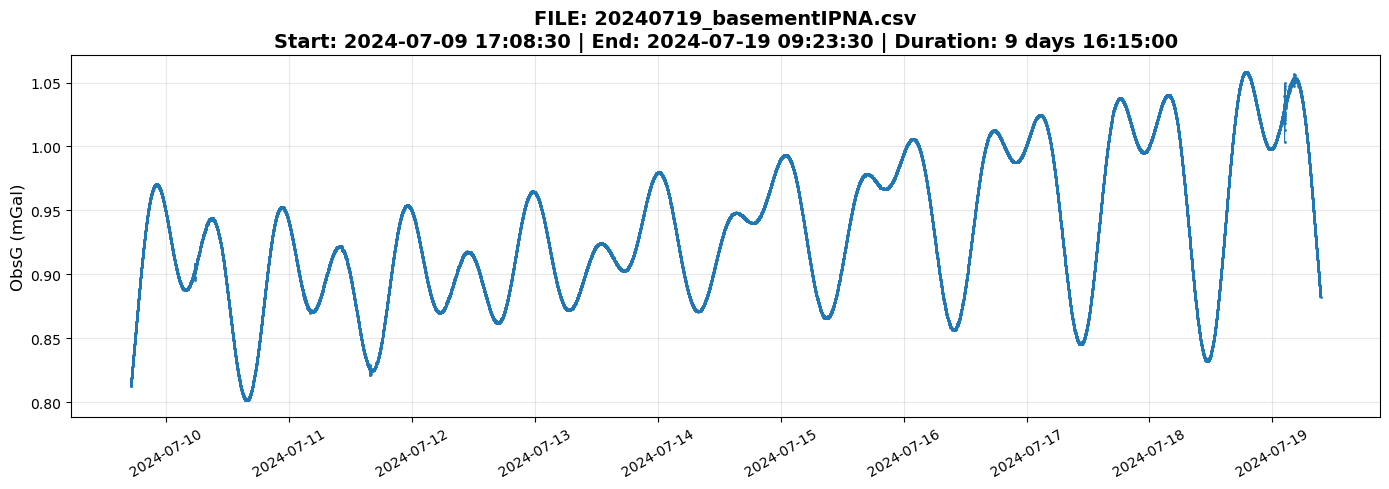

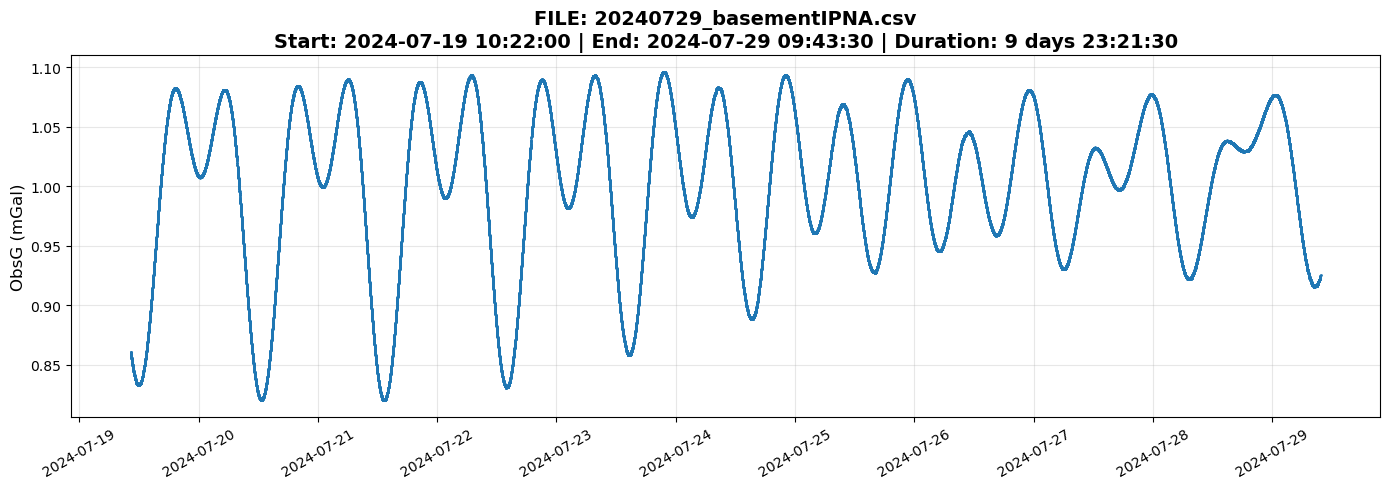

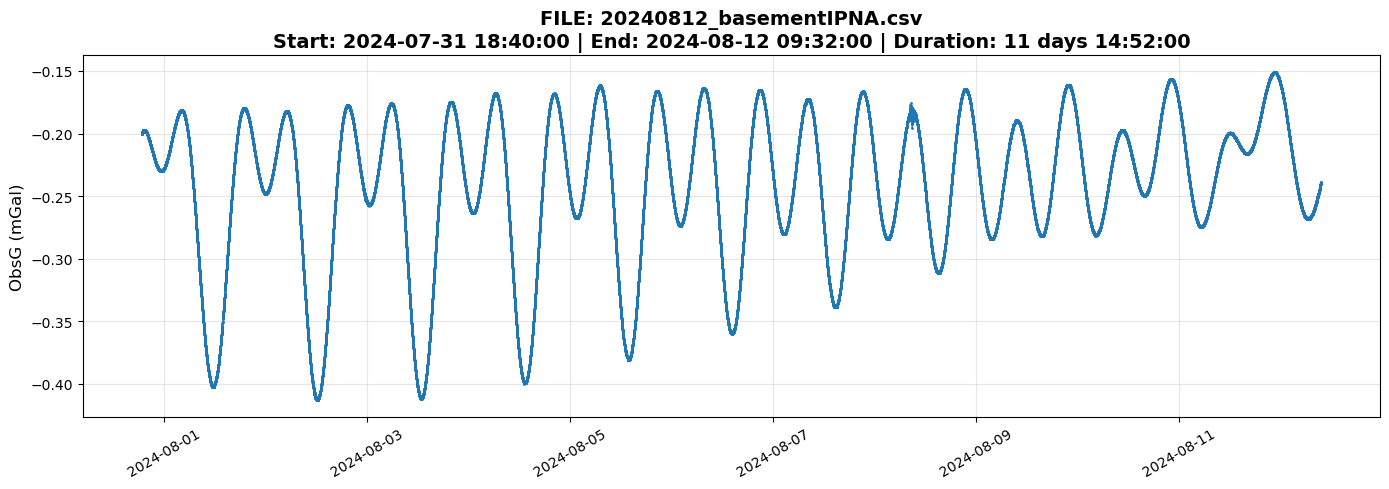

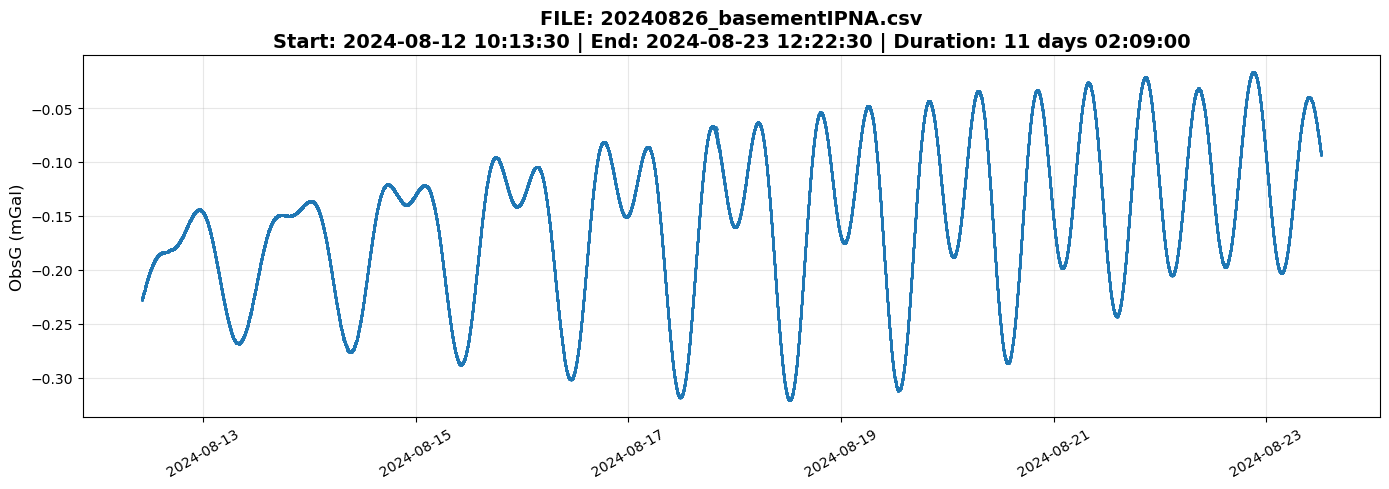

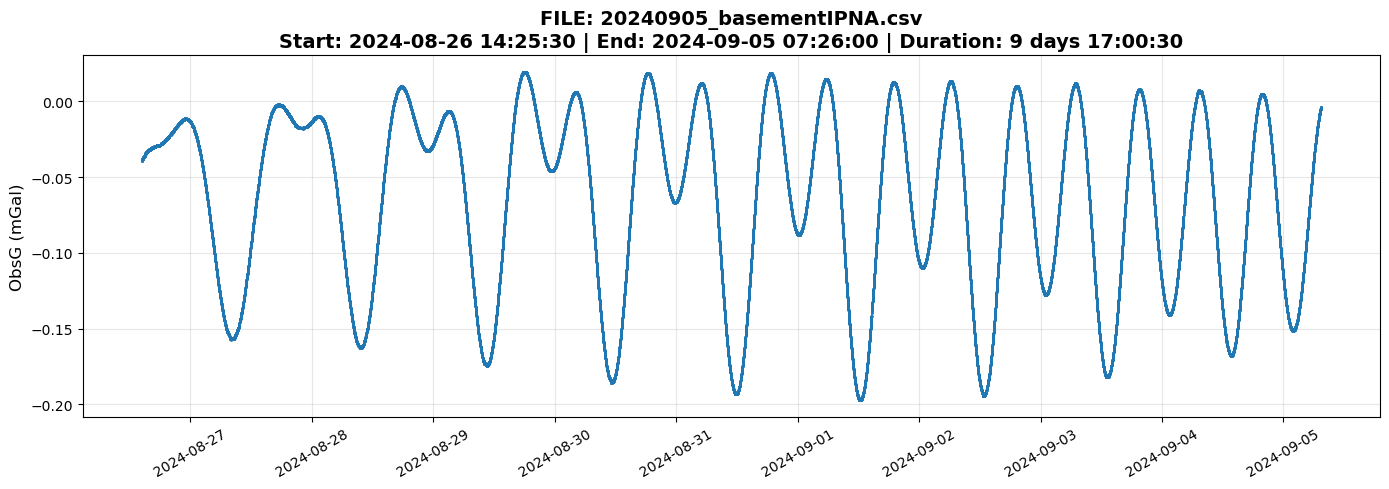

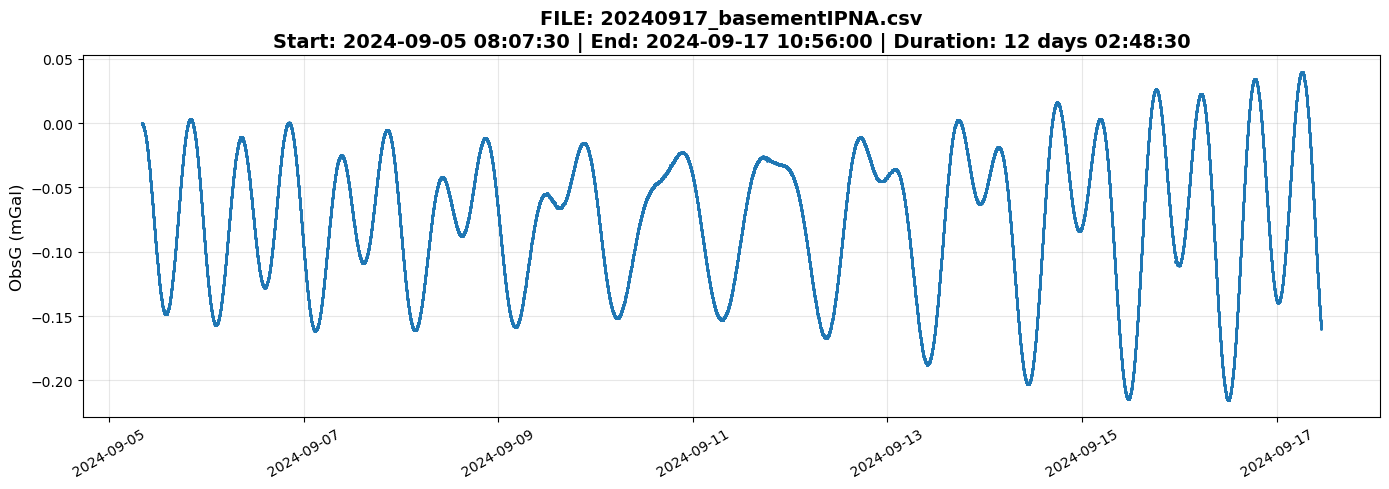

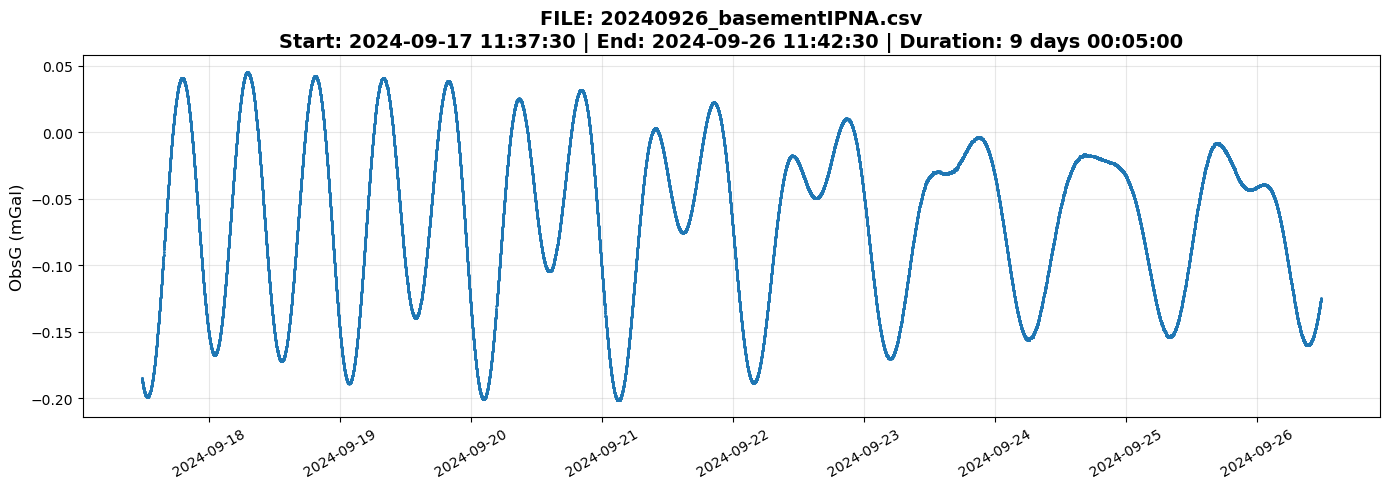

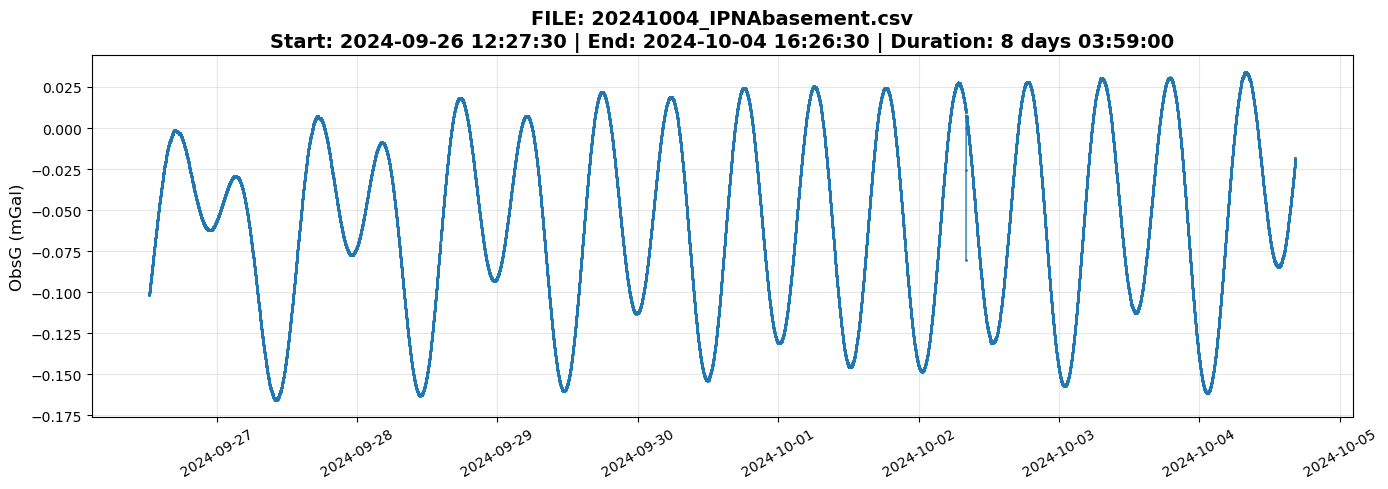

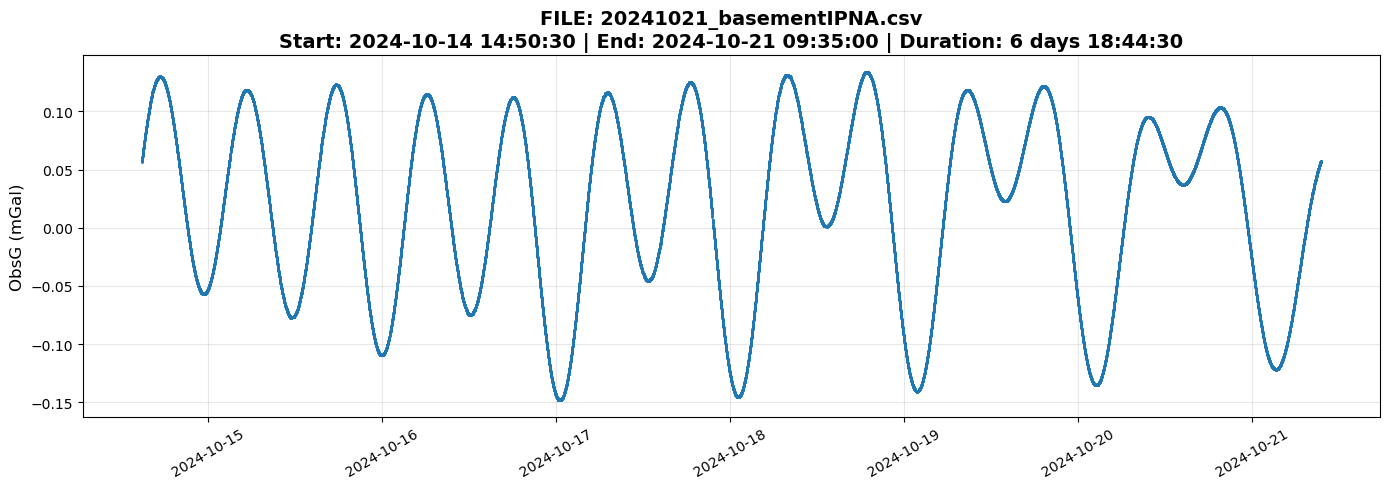

In [6]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# 1. Liste des fichiers
path = "Continuous_files_basement/"
all_files = glob.glob(os.path.join(path, "*.csv"))
all_files.sort()

# 2. Boucle d'affichage simple
for f in all_files:
    # Chargement
    df_temp = pd.read_csv(f)
    
    # Conversion date/heure
    df_temp['datetime'] = pd.to_datetime(df_temp['Date'] + ' ' + df_temp['Time'])
    
    # Infos pour le titre
    start_f = df_temp['datetime'].min()
    end_f = df_temp['datetime'].max()
    duration = end_f - start_f
    
    # Création du Plot
    plt.figure(figsize=(14, 5))
    
    # On trace les données (le 'o-' crée le trait, 'o' seul ne le ferait pas)
    plt.plot(df_temp['datetime'], df_temp['ObsG'], 'o-', markersize=1, linewidth=0.5)
    
    # Titre avec les dates et la durée
    plt.title(f"FILE: {os.path.basename(f)}\nStart: {start_f} | End: {end_f} | Duration: {duration}", 
              fontsize=14, fontweight='bold')
    
    plt.ylabel("ObsG (mGal)", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=30)
    
    plt.tight_layout()
    plt.show()

### Correction (solid earth) and Offset

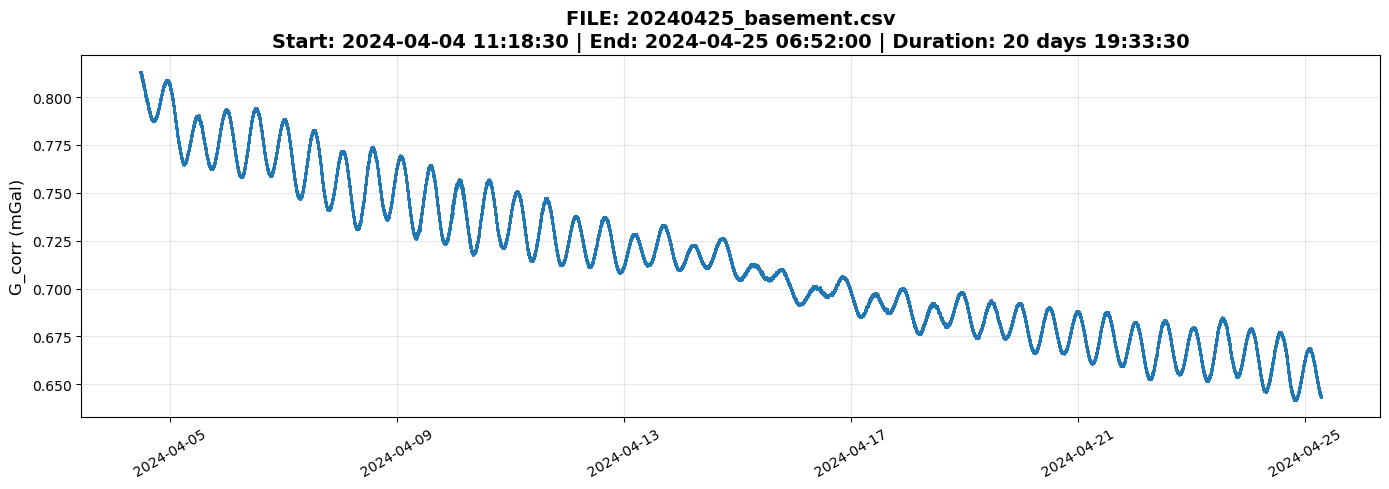

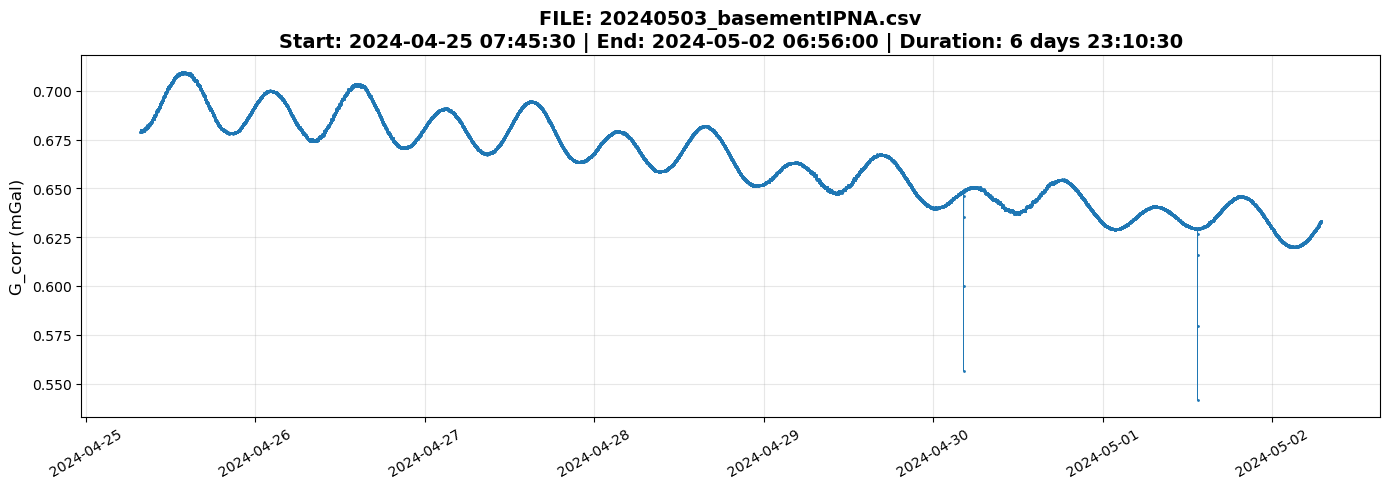

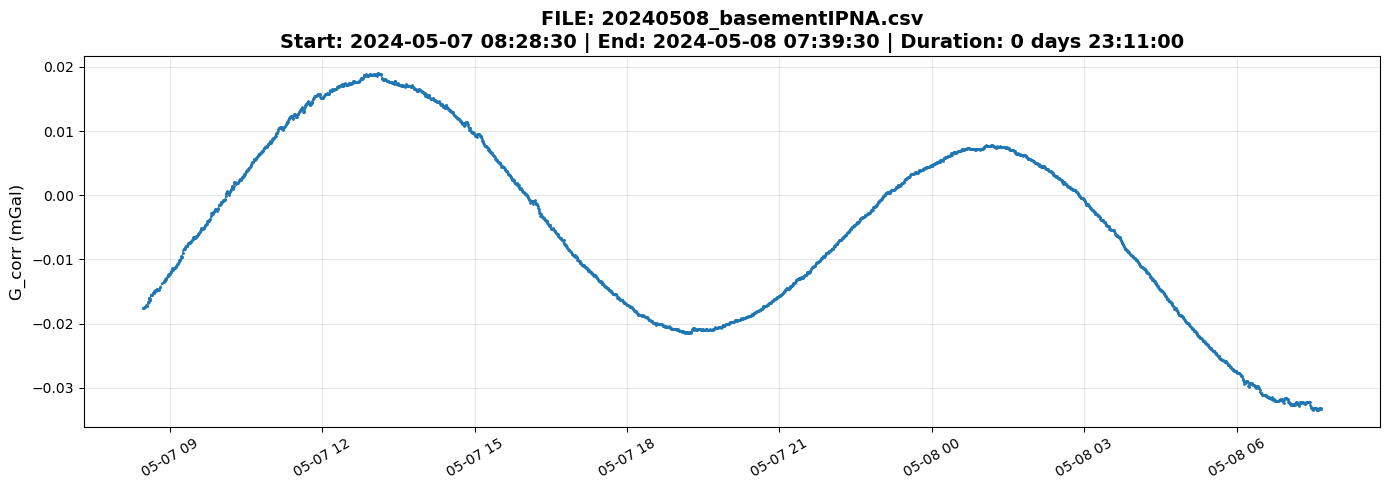

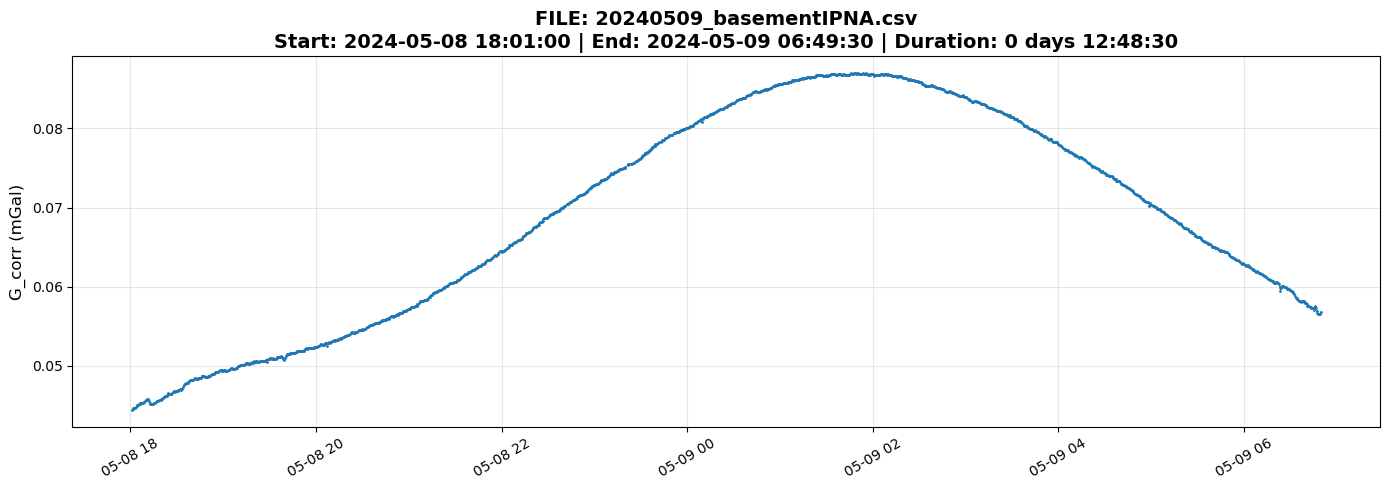

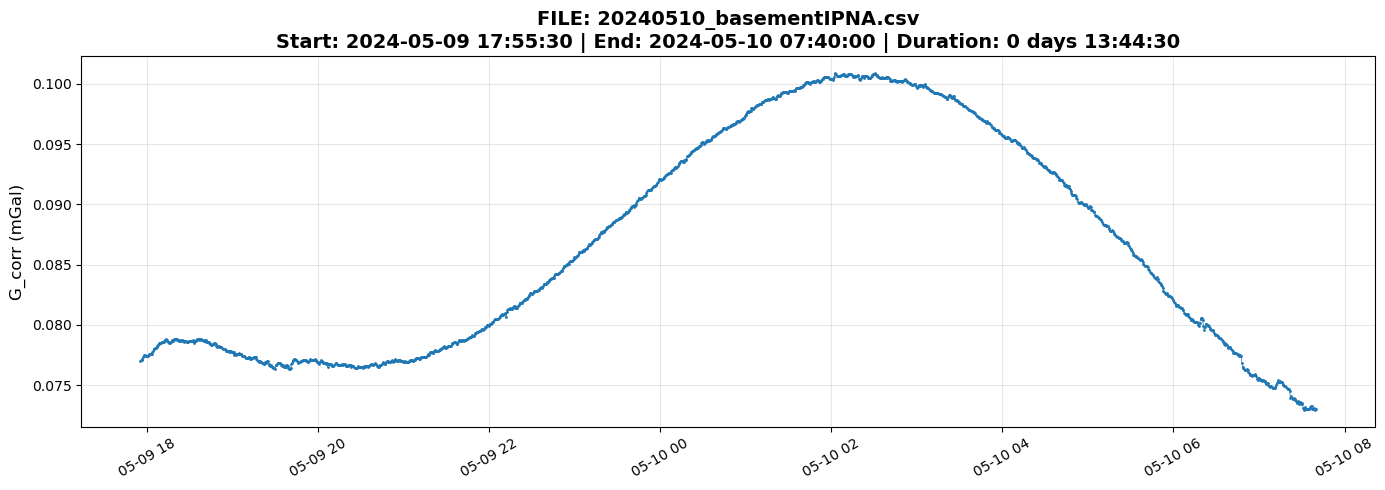

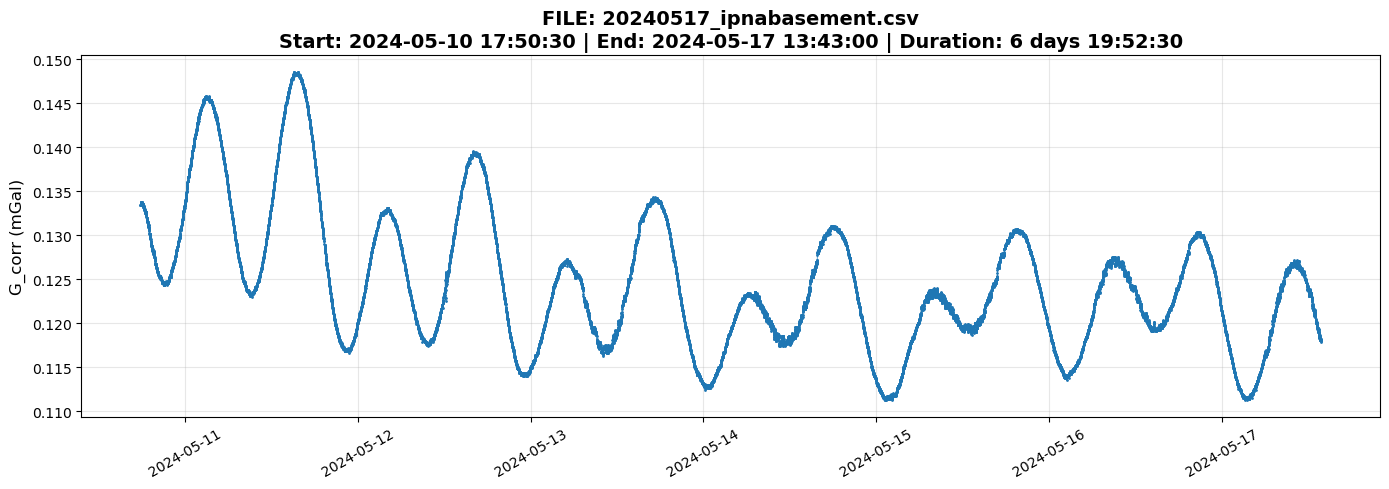

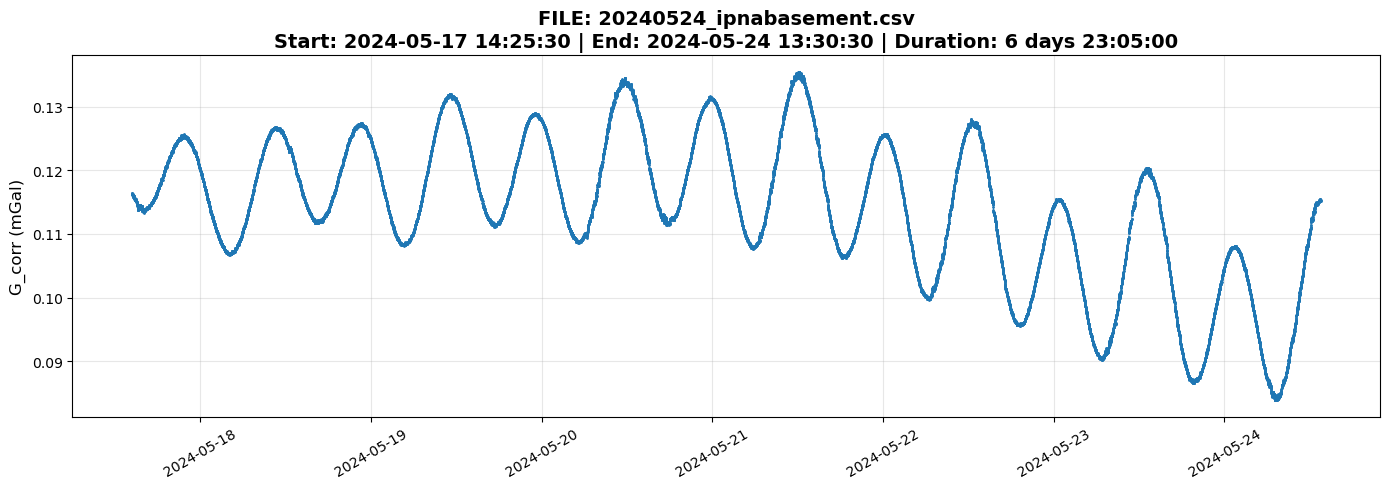

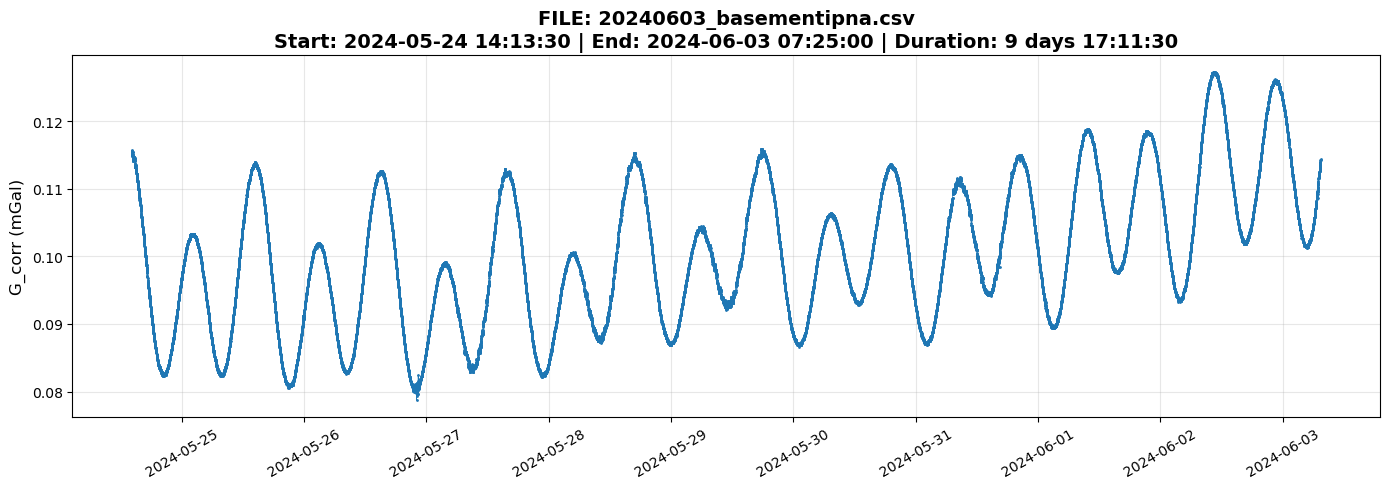

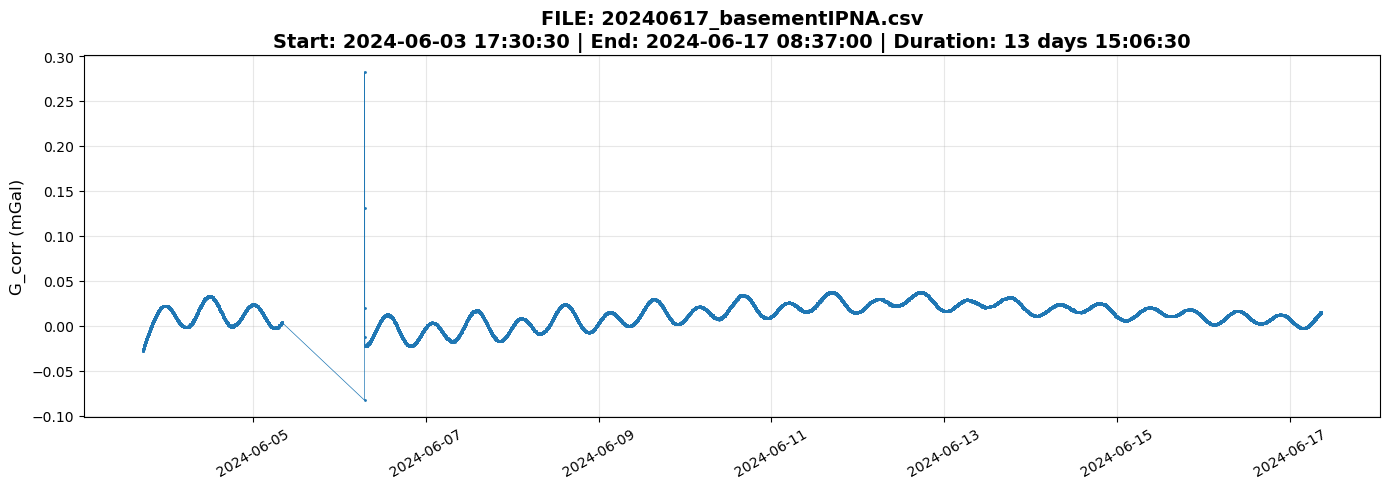

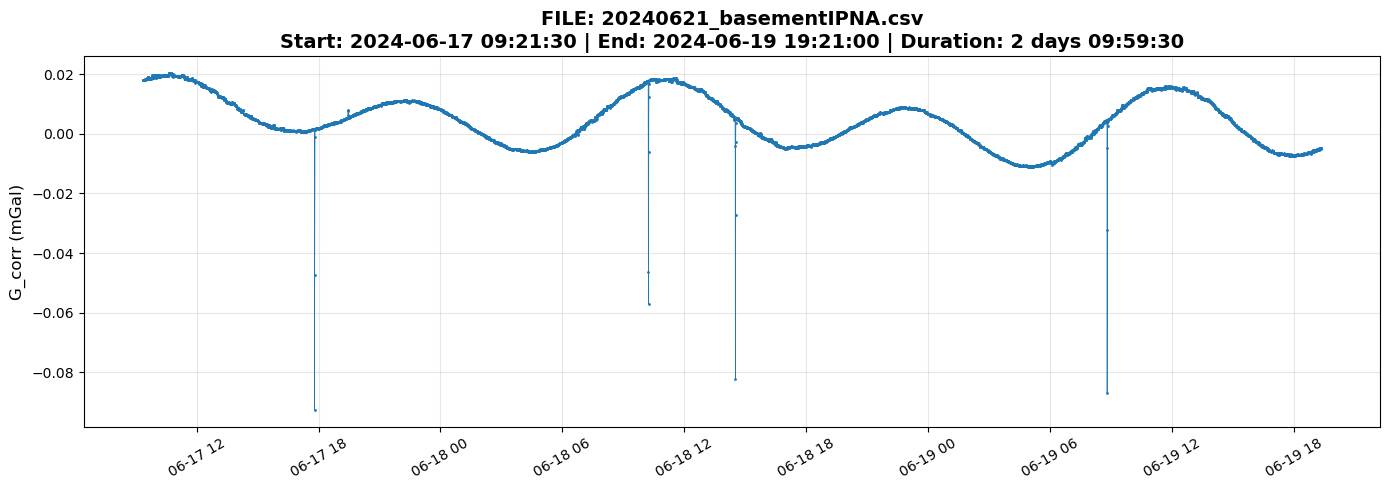

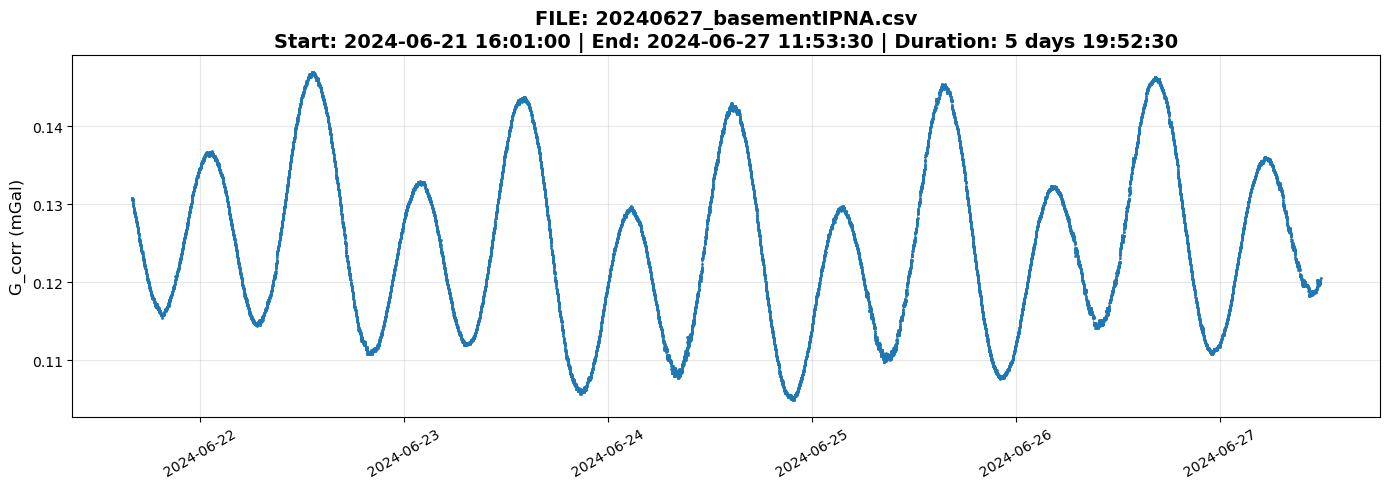

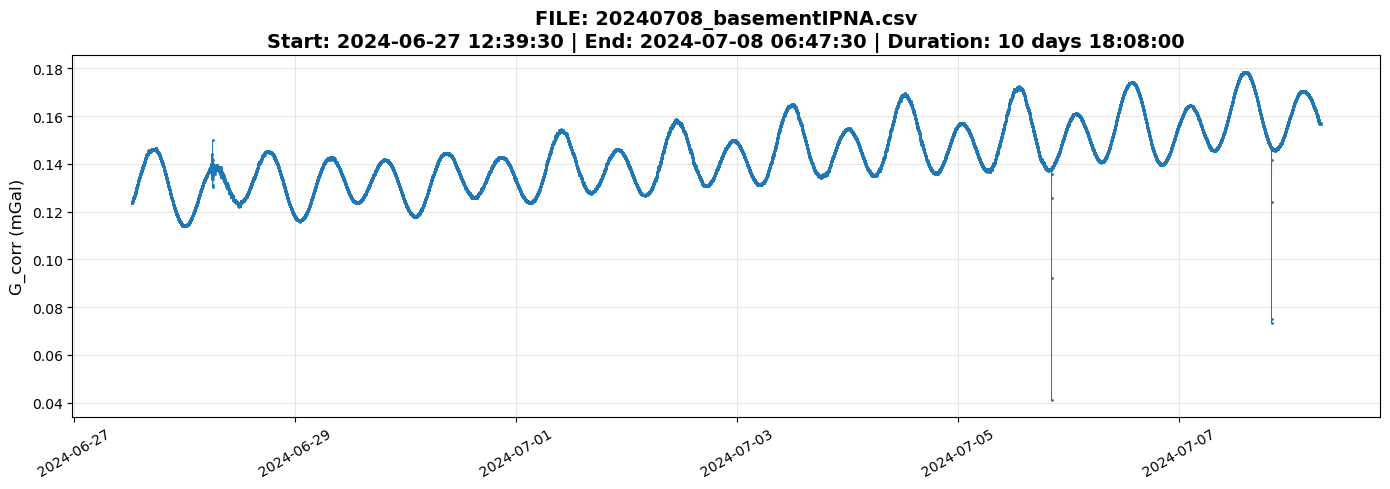

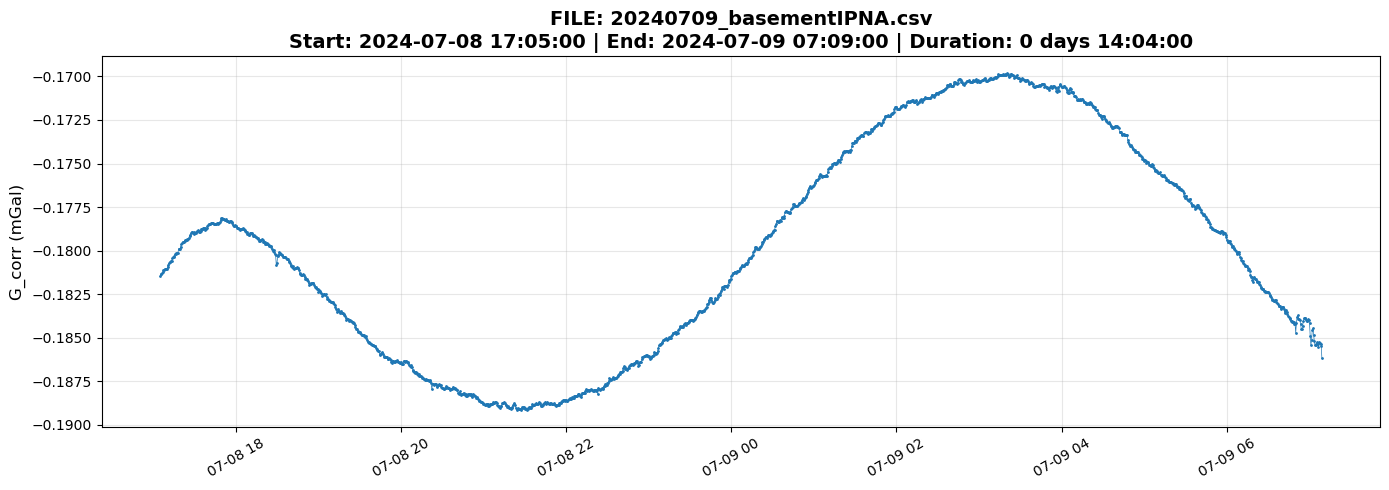

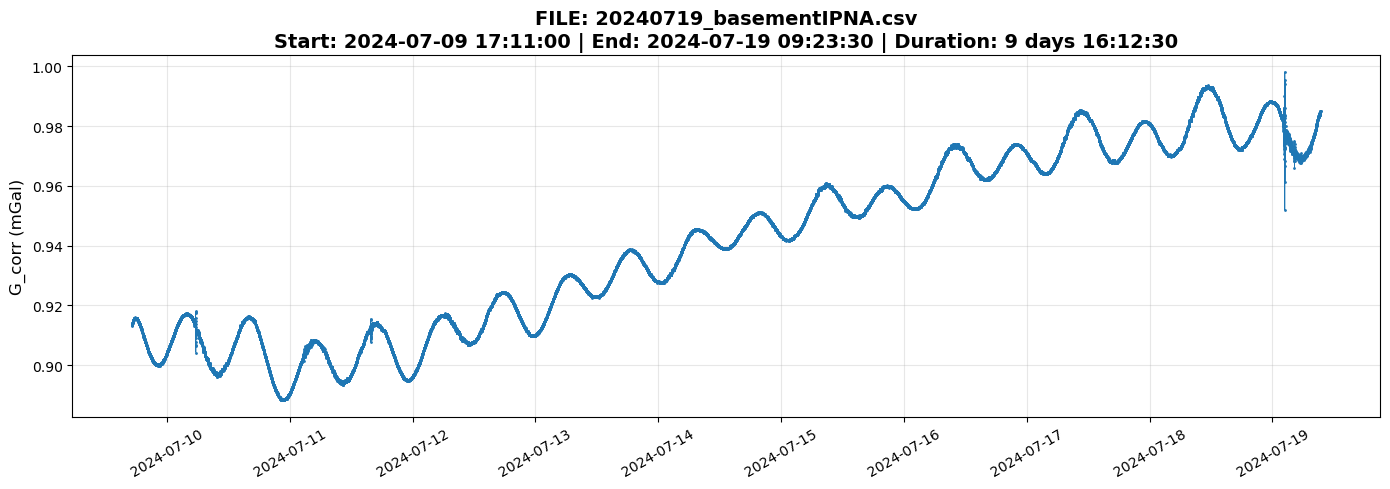

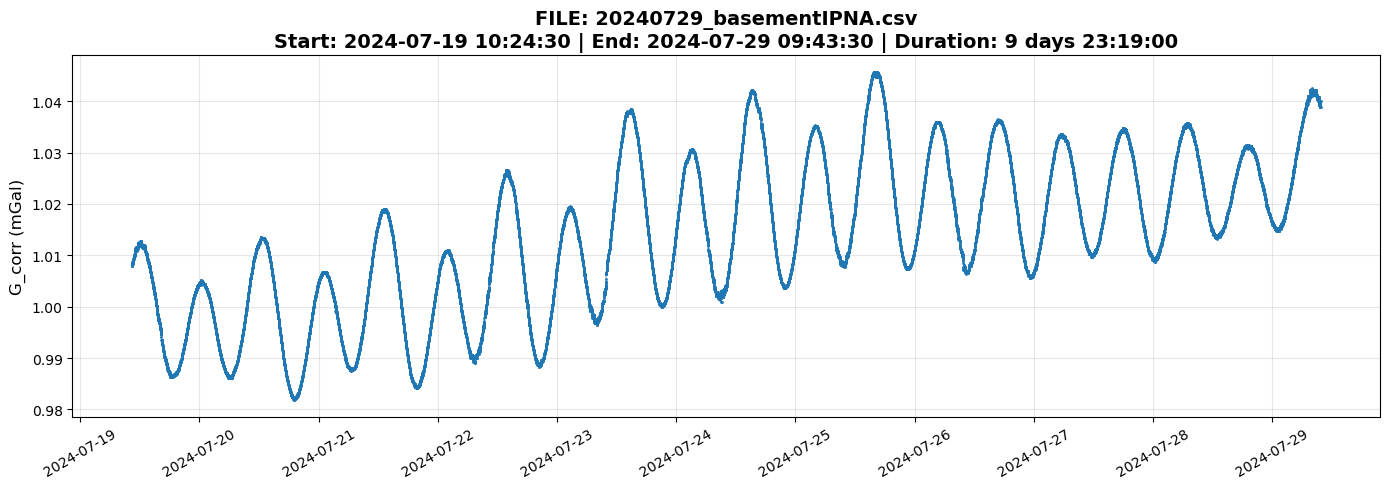

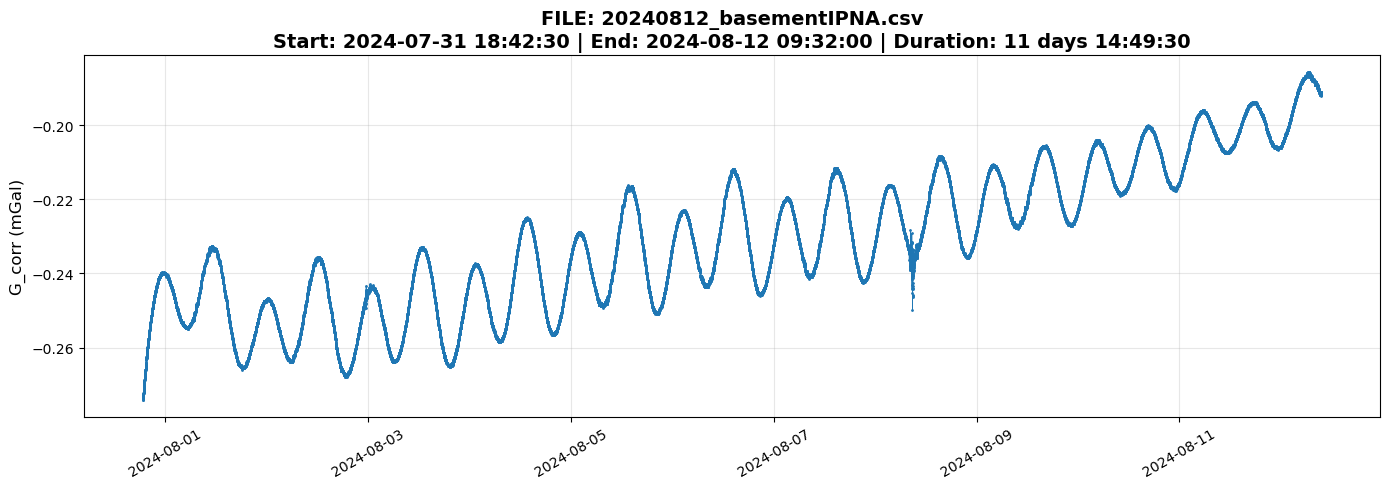

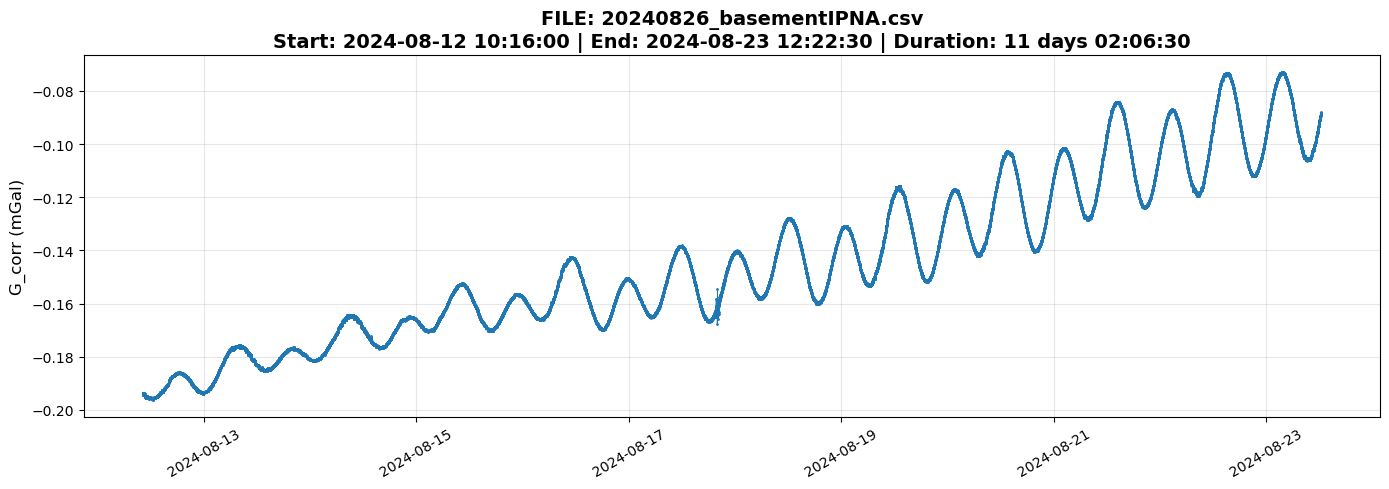

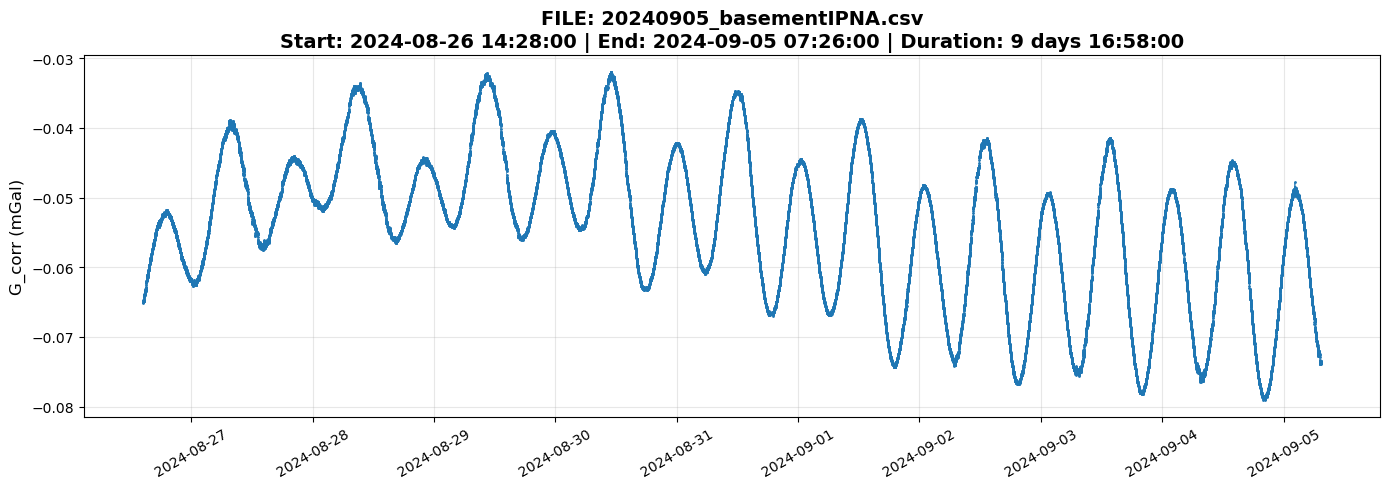

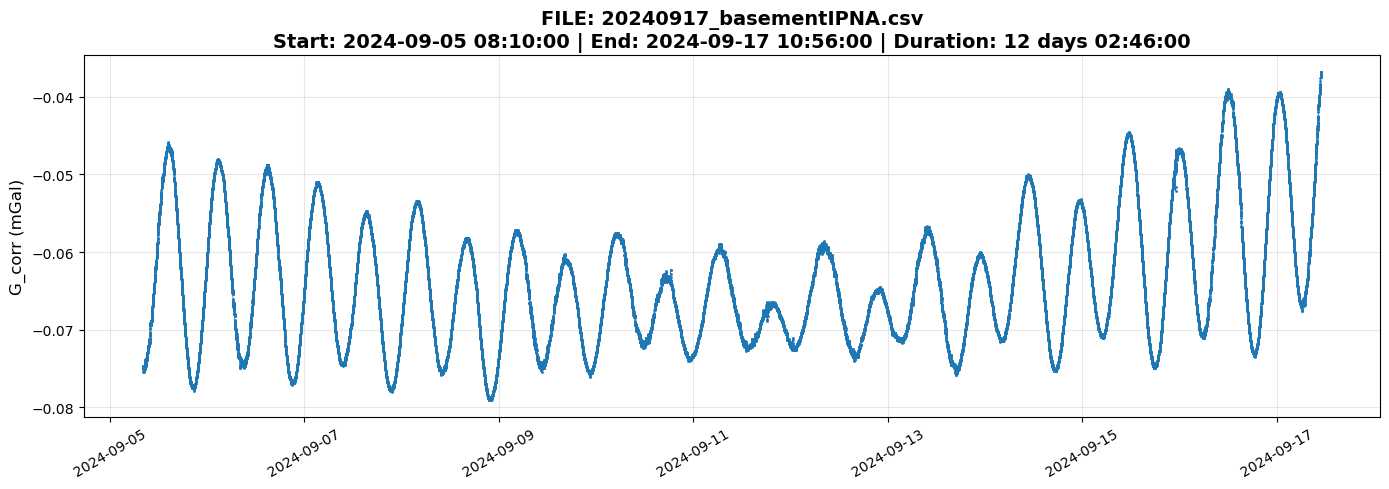

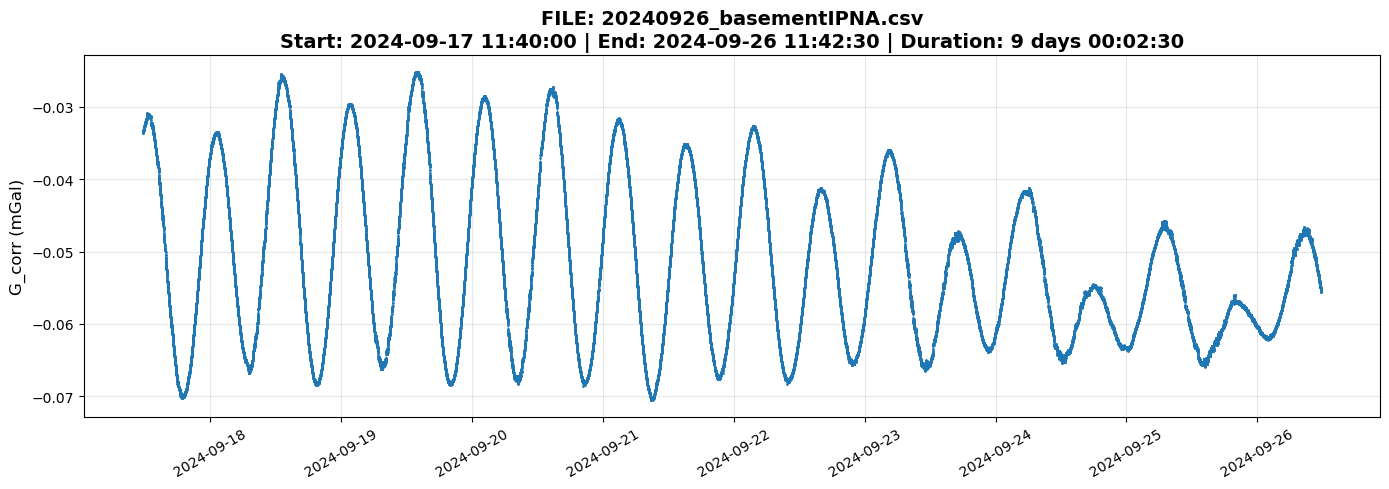

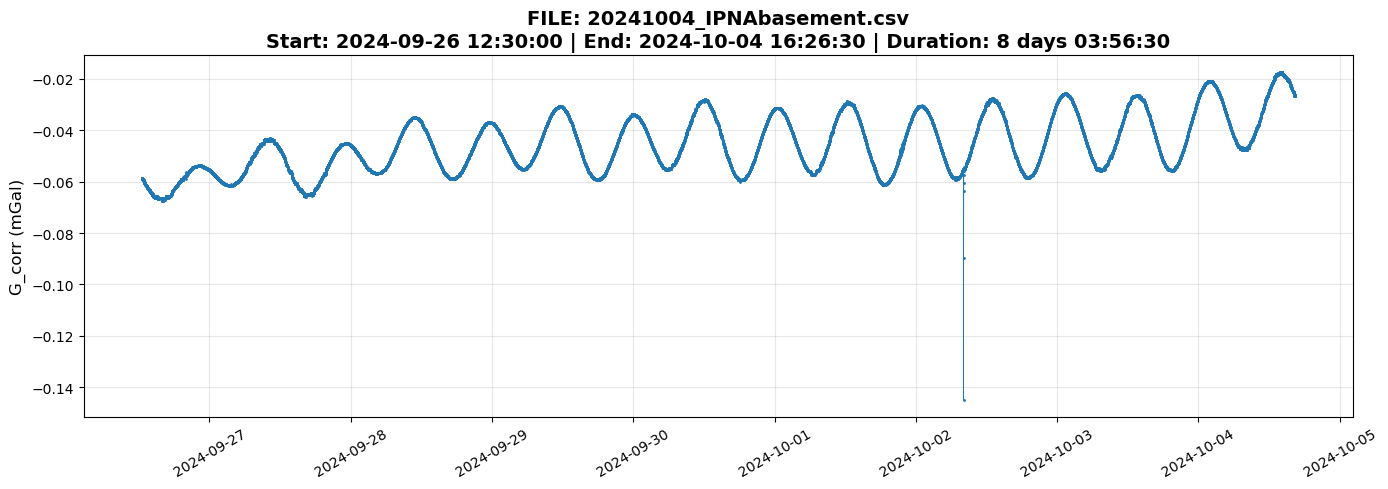

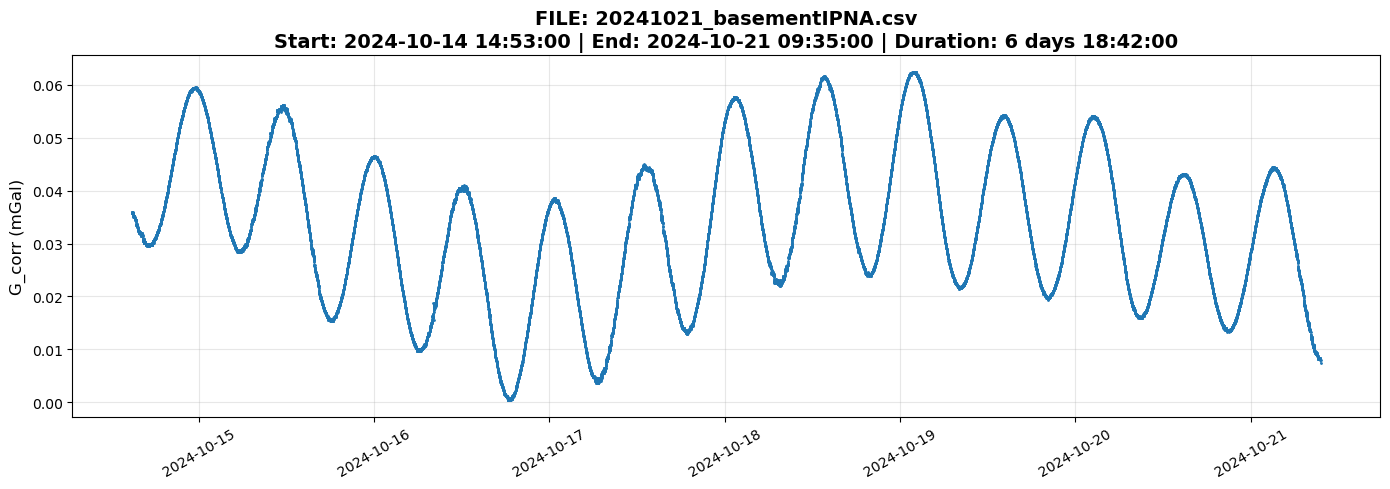

In [7]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import numpy as np

path = "Continuous_files_basement/"
all_files = glob.glob(os.path.join(path, "*.csv"))
all_files.sort()

# Dates de l'erreur du 28/06
debut_err = pd.to_datetime('2024-06-28 06:15:00')
fin_err   = pd.to_datetime('2024-06-28 06:33:00')

for f in all_files:
    df = pd.read_csv(f)
    
    # 1. Création de la colonne datetime pour le filtrage
    df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

    # 2. Omettre les 5 premières lignes (stabilisation)
    df = df.iloc[5:].copy()
    
    # 3. Calcul de G_corr
    df['G_corr'] = df['ObsG'] - df['Earthtide']

    # --- NOUVEAU : NETTOYAGE SPÉCIFIQUE DU 28/06 ---
    # On regarde si ce fichier contient la période du 28 juin
    mask_noise = (df['datetime'] >= debut_err) & (df['datetime'] <= fin_err)
    
    # On remplace les valeurs de G_corr par NaN pour ces dates
    df.loc[mask_noise, 'G_corr'] = np.nan
    # -----------------------------------------------
    
    # 4. Sauvegarder (avec la colonne G_corr nettoyée et datetime)
    df.to_csv(f, index=False)

    # --- PLOT ---
    plt.figure(figsize=(14, 5))

    # Infos pour le titre
    start_f = df['datetime'].min()
    end_f = df['datetime'].max()
    duration = end_f - start_f

    # Note : Matplotlib ne trace pas les points qui sont "NaN"
    # Le 'o-' créera une cassure dans la ligne là où se trouvait l'erreur
    plt.plot(df['datetime'], df['G_corr'], 'o-', markersize=1, linewidth=0.5)
    
    # Titre avec les dates et la durée
    plt.title(f"FILE: {os.path.basename(f)}\nStart: {start_f} | End: {end_f} | Duration: {duration}", 
              fontsize=14, fontweight='bold')
    
    plt.ylabel("G_corr (mGal)", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=30)
    
    plt.tight_layout()
    plt.show()

Série de 500516 points
Valeurs Max et Min : 1.045733, -0.274243 mGal
Amplitude du Drift : 1.3200 mGal


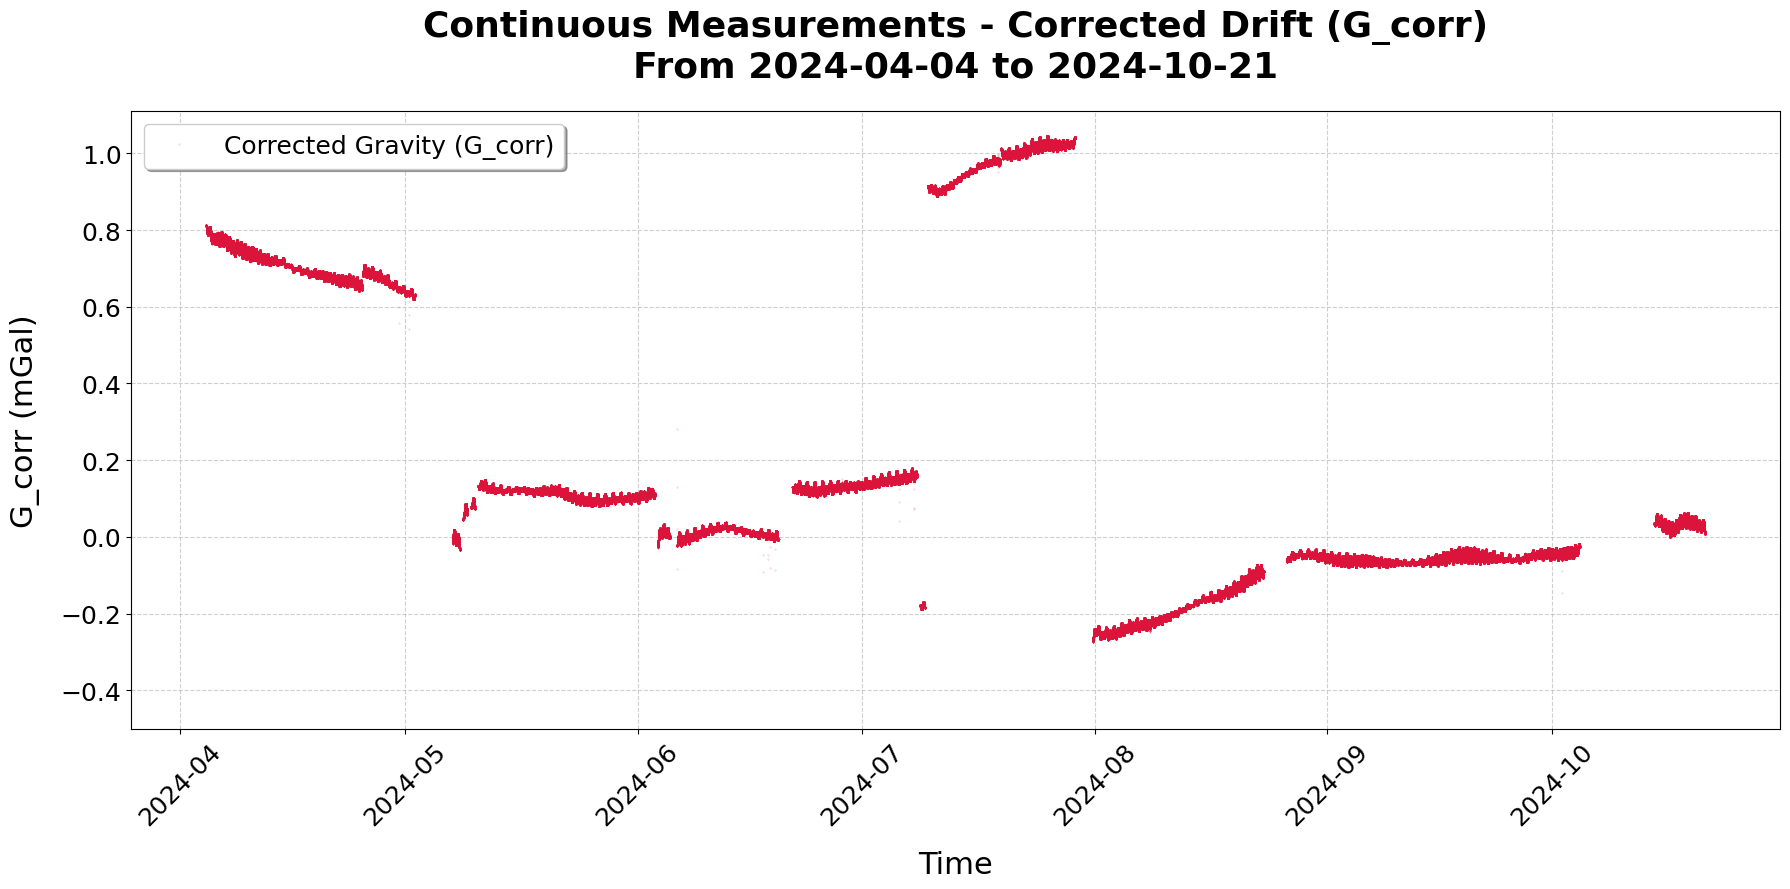

In [8]:
# large plot
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# 1. CHARGEMENT DES DONNÉES
path = "Continuous_files_basement/"
all_files = glob.glob(os.path.join(path, "*.csv"))
all_files.sort() 

df_list = [pd.read_csv(f) for f in all_files]
G_total = pd.concat(df_list, ignore_index=True)

# 2. TIMELINE ET TRI
G_total['datetime'] = pd.to_datetime(G_total['Date'] + ' ' + G_total['Time'])
G_total = G_total.sort_values('datetime')

# Statistiques pour info
val_max = G_total['G_corr'].max()
val_min = G_total['G_corr'].min()
print(f"Série de {len(G_total)} points")
print(f"Valeurs Max et Min : {val_max}, {val_min} mGal")
print(f"Amplitude du Drift : {val_max - val_min:.4f} mGal")

# 3. LE GROS PLOT
plt.figure(figsize=(18, 9))

# Plot de G_corr (en rouge pour marquer la correction)
plt.plot(G_total['datetime'], G_total['G_corr'], 'o', 
         markersize=0.2, alpha=0.5, color='crimson', label='Corrected Gravity (G_corr)')

# Titres et labels
start_date = G_total['datetime'].min().date()
end_date = G_total['datetime'].max().date()
plt.title(f"Continuous Measurements - Corrected Drift (G_corr)\nFrom {start_date} to {end_date}", 
          fontsize=26, fontweight='bold', pad=25)
plt.xlabel("Time", fontsize=22, labelpad=15)
plt.ylabel("G_corr (mGal)", fontsize=22, labelpad=15)
plt.ylim(-0.5,1.11)

plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(fontsize=18, loc='upper left', frameon=True, shadow=True)

plt.xticks(rotation=45, fontsize=18) 
plt.yticks(fontsize=18)

plt.tight_layout()
plt.show()

### GOOD OFFSETS : rabotage auto + manuel avec zoom

In [10]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. CONFIGURATION ET CHARGEMENT DU BASEMENT
path = "Continuous_files_basement/"
all_files = glob.glob(os.path.join(path, "*.csv"))
all_files.sort()

# --- CHARGEMENT ET NETTOYAGE DU SURVEY (Ténérife) ---
G_survey = pd.read_csv("Final_Precise_Raw_Gravity_Data.csv", sep=';', decimal=',')
G_survey['datetime'] = pd.to_datetime(G_survey['Date'] + ' ' + G_survey['Time'])

# --- TON TABLEAU DE BORD POUR LES AJUSTEMENTS ---
ajustements = {i: 0.0 for i in range(len(all_files))}
# Exemples d'utilisation :
ajustements[2] = -0.07
ajustements[13] = 0.04
ajustements[15] = -0.04
ajustements[17] = 0.02

data_blocks = []
current_total_offset = 0

for i, f in enumerate(all_files):
    df = pd.read_csv(f)
    df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
    df = df.sort_values('datetime')
    
    if i > 0:
        val_end_prev = data_blocks[i-1]['G_corr'].tail(10).median()
        val_start_curr = df['G_corr'].head(10).median()
        step_offset = val_end_prev - val_start_curr
        current_total_offset += (step_offset + ajustements[i])
        
    df['G_final'] = df['G_corr'] + current_total_offset
    df['file_index'] = i
    data_blocks.append(df)

G_total = pd.concat(data_blocks, ignore_index=True)

# ---------------------------------------------------------
# 2. FONCTION DE ZOOM (AVEC TIMELINE SURVEY)
# ---------------------------------------------------------
def plot_zoom_2months(df_zoom, title, df_survey_total):
    plt.figure(figsize=(20, 10))
    
    # --- TRACÉ BASEMENT ---
    # Points réels (finesse 0.1) sans label
    indices_dans_zoom = df_zoom['file_index'].unique()
    for idx in indices_dans_zoom:
        block = df_zoom[df_zoom['file_index'] == idx].copy()
        plt.plot(block['datetime'], block['G_final'], 'o', markersize=0.3, alpha=0.4, color='darkblue')
        
        # Bords en rouge
        if len(block) > 100:
            plt.plot(block.iloc[:50]['datetime'], block.iloc[:50]['G_final'], 'o', markersize=1.8, color='red')
            plt.plot(block.iloc[-50:]['datetime'], block.iloc[-50:]['G_final'], 'o', markersize=1.8, color='red')
        
        # Étiquette ID
        mid_time = block['datetime'].iloc[len(block)//2]
        plt.text(mid_time, block['G_final'].median() + 0.015, f"{idx}", 
                 fontsize=20, fontweight='bold', color='red', ha='center', 
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    # --- TRACÉ TIMELINE SURVEY (Orange) ---
    # On filtre le survey pour ne garder que la période du zoom
    mask_s = (df_survey_total['datetime'] >= df_zoom['datetime'].min()) & \
             (df_survey_total['datetime'] <= df_zoom['datetime'].max())
    survey_window = df_survey_total.loc[mask_s]

    if not survey_window.empty:
        plt.plot(survey_window['datetime'], [0.41] * len(survey_window), '|', 
                 markersize=20, mew=3, color='darkorange')

    # --- ASTUCE LÉGENDE PROPRE ---
    plt.plot([], [], 'o', markersize=10, color='darkblue', label='Basement')
    plt.plot([], [], '|', markersize=15, mew=3, color='darkorange', label='Périodes Survey')
    plt.legend(loc='upper left', fontsize=15)

    # Configuration axes
    plt.title(title, fontsize=20, fontweight='bold')
    plt.ylabel("G_corr Aligné (mGal)", fontsize=18)
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.xticks(rotation=45, fontsize=18)
    plt.yticks(fontsize=18)
    plt.ylim(0.4, 1.1)
    
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 3. GÉNÉRATION DES ZOOMS
# ---------------------------------------------------------
start_full = G_total['datetime'].min()
end_full = G_total['datetime'].max()
current_start = start_full

while current_start < end_full:
    current_end = current_start + pd.Timedelta(days=60)
    mask = (G_total['datetime'] >= current_start) & (G_total['datetime'] < current_end)
    df_window = G_total.loc[mask]
    if not df_window.empty:
        plot_zoom_2months(df_window, f"DÉTAIL JONCTIONS : {current_start.date()} au {current_end.date()}", G_survey)
    current_start = current_end - pd.Timedelta(days=10)

# ---------------------------------------------------------
# 4. GROS PLOT ENTIER (RÉCAPITULATIF)
# ---------------------------------------------------------
plt.figure(figsize=(20, 10))

# Basement
plt.plot(G_total['datetime'], G_total['G_final'], 'o', markersize=0.1, alpha=0.5, color='darkblue')

# Timeline Survey complète
plt.plot(G_survey['datetime'], [0.41] * len(G_survey), '|', markersize=20, mew=3, color='darkorange')

# Légende Fantôme
plt.plot([], [], 'o', markersize=10, color='darkblue', label='Basement')
plt.plot([], [], '|', markersize=15, mew=3, color='darkorange', label='Périodes Survey')
plt.legend(loc='upper left', fontsize=15)

plt.title(f"COMPLETE DRIFT ALIGNED & SURVEY TIMELINE\nFrom {start_full.date()} to {end_full.date()}", fontsize=24, fontweight='bold')
plt.xlabel("Time", fontsize=18)
plt.ylabel("Gravity (mGal)", fontsize=18)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, fontsize=18)
plt.yticks(fontsize=18)
plt.ylim(0.4, 1.1)

# Repères ID
for i in range(0, len(data_blocks), max(1, len(all_files)//15)):
    df_b = data_blocks[i]
    plt.text(df_b['datetime'].iloc[len(df_b)//2], 
             df_b['G_final'].median() + 0.03, 
             f"{i}", 
             color='red', fontsize=18, fontweight='bold',
             ha='center', va='bottom') # Centré horizontalement, base en bas

plt.tight_layout()
plt.show()

ValueError: No objects to concatenate